# MTAOS Z4 (Focus / Defocus) Trends — Nightly Timeline and AOS FWHM Correlation

Queries `lsst.sal.MTAOS.logevent_wavefrontError` from the EFD to retrieve
per-cycle Z4 (Noll defocus, `nollZernikeValues0`, units: µm) measured by the
four corner wavefront sensors. Joins to ConsDB `visit1_quicklook` via
`visitId` to correlate with `aos_fwhm`.

### What this notebook produces
1. **Nightly median Z4 timeline** — night-by-night median and IQR across all corner sensors.
2. **Nightly Z4 RMS (intra-night spread)** — how much focus varies within each night.
3. **Per-sensor nightly timeline** — individual tracks for the four corner sensors.
4. **Z4 vs `aos_fwhm` scatter** — density plots of the defocus–FWHM relationship.


## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlalchemy

from astropy.time import Time, TimeDelta
import astropy.units as u
from lsst_efd_client import EfdClient

%matplotlib inline

## Configuration

In [2]:
# ── Time window ───────────────────────────────────────────────────────────────
t_end   = Time("2026-06-08T12:00:00", scale="utc")
t_start = t_end - TimeDelta(90 * u.day)
print(f"EFD window: {t_start.iso}  →  {t_end.iso}")

day_obs_start = int(t_start.strftime("%Y%m%d"))
day_obs_end   = int(t_end.strftime("%Y%m%d"))
print(f"day_obs range: {day_obs_start} – {day_obs_end}")

# ── EFD ───────────────────────────────────────────────────────────────────────
EFD_ALIAS = "usdf_efd"
WFE_TOPIC = "lsst.sal.MTAOS.logevent_wavefrontError"
N_NOLL_VALUES = 25        # Z4–Z28
NOLL_OFFSET   = 4         # first Noll index

# ── Corner sensor ID → label ──────────────────────────────────────────────────
# Each corner raft has two wavefront sensors: SW0 (odd ID) and SW1 (even ID).
SENSOR_LABELS = {
    191: "R00 SW0",  192: "R00 SW1",
    195: "R04 SW0",  196: "R04 SW1",
    199: "R40 SW0",  200: "R40 SW1",
    203: "R44 SW0",  204: "R44 SW1",
}
SENSOR_COLORS = {
    191: "steelblue",   192: "steelblue",
    195: "tomato",      196: "tomato",
    199: "mediumseagreen", 200: "mediumseagreen",
    203: "darkorchid",  204: "darkorchid",
}
# SW0 = solid line, SW1 = dashed
SENSOR_LS = {sid: ("-" if sid % 2 == 1 else "--") for sid in SENSOR_LABELS}

# ── ConsDB / PostgreSQL ───────────────────────────────────────────────────────
PGPASS_FILE = os.path.expanduser("~/.lsst/postgres-credentials.txt")
CONSDB_HOST = "usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu"
CONSDB_DB   = "exposurelog"
CONSDB_USER = "usdf"
SCHEMA      = "cdb_lsstcam"

def load_pgpass(path, host, database, user):
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(":")
            if len(parts) >= 5 and parts[0] == host and parts[2] == database and parts[3] == user:
                return ":".join(parts[4:])
    raise ValueError(f"No credentials for {user}@{host}/{database}")

db_pass = load_pgpass(PGPASS_FILE, CONSDB_HOST, CONSDB_DB, CONSDB_USER)
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{CONSDB_USER}:{db_pass}@{CONSDB_HOST}/{CONSDB_DB}",
    connect_args={"connect_timeout": 30},
)

def consdb_query(sql):
    with engine.connect() as conn:
        return pd.read_sql_query(sqlalchemy.text(sql), conn)

print("Config ready.")
# ── Parquet cache ────────────────────────────────────────────────────────────
CACHE_FILE      = "../data/z4_wfe.parquet"
GRAD_CACHE_FILE = "../data/z4_m1m3_gradients.parquet"
FORCE_REFETCH   = False   # True → ignore cache, re-fetch everything


EFD window: 2026-03-10 12:00:00.000  →  2026-06-08 12:00:00.000
day_obs range: 20260310 – 20260608
Config ready.


## 1. Fetch Z4 from EFD

Each row of `logevent_wavefrontError` is one AOS cycle measurement for one
corner sensor. `nollZernikeValues0` = Z4 (Noll defocus) in **µm**.
`visitId` links back to ConsDB exposures.


In [3]:
import pathlib as _pl

efd_client = EfdClient(EFD_ALIAS)
print(f"Connected to EFD alias: {EFD_ALIAS}")

_from_cache = False
if not FORCE_REFETCH and _pl.Path(CACHE_FILE).exists():
    df_wfe = pd.read_parquet(CACHE_FILE)
    df_wfe["z4_um"] = pd.to_numeric(df_wfe["z4_um"], errors="coerce")
    _from_cache = True
    print(f"\u2713 Loaded {len(df_wfe)} EFD rows from cache: {CACHE_FILE}")
    print(f"Time range: {df_wfe.index.min()}  \u2192  {df_wfe.index.max()}")
    print(f"Unique sensorIds: {sorted(df_wfe['sensorId'].unique())}")
    print(f"Z4 range: {df_wfe['z4_um'].min():.3f} to {df_wfe['z4_um'].max():.3f} \u00b5m")
else:
    noll_val_fields = [f"nollZernikeValues{i}" for i in range(N_NOLL_VALUES)]
    df_wfe = await efd_client.select_time_series(
        WFE_TOPIC,
        fields=["sensorId", "visitId"] + noll_val_fields,
        start=t_start,
        end=t_end,
    )
    print(f"Rows returned: {len(df_wfe)}")
    if df_wfe.empty:
        print("No data \u2014 widen the time window or check EFD alias.")
    else:
        print(f"Time range: {df_wfe.index.min()}  \u2192  {df_wfe.index.max()}")
        print(f"Unique sensorIds: {sorted(df_wfe['sensorId'].unique())}")
        df_wfe["z4_um"] = pd.to_numeric(df_wfe["nollZernikeValues0"], errors="coerce")
        print(f"Z4 range: {df_wfe['z4_um'].min():.3f} to {df_wfe['z4_um'].max():.3f} \u00b5m")
        display(df_wfe[["sensorId", "visitId", "z4_um"]].head(6))
        df_wfe[["sensorId", "visitId", "z4_um"]].to_parquet(CACHE_FILE)
        print(f"\u2713 Saved {len(df_wfe)} rows \u2192 {CACHE_FILE}")


Connected to EFD alias: usdf_efd
✓ Loaded 93940 EFD rows from cache: ../data/z4_wfe.parquet
Time range: 2026-03-11 00:24:41.539403+00:00  →  2026-06-08 10:37:03.797264+00:00
Unique sensorIds: [np.int64(191), np.int64(192), np.int64(195), np.int64(196), np.int64(199), np.int64(200), np.int64(203), np.int64(204)]
Z4 range: -10.177 to 6.445 µm


## 2. Fetch `aos_fwhm` from ConsDB

Pull `visit_id` and image-quality metrics from `visit1_quicklook` for the
same window so we can join on `visitId`.


In [4]:
sql = (
    f"SELECT e.day_obs, q.visit_id, q.aos_fwhm, q.donut_blur_fwhm, "
    f"q.psf_sigma_median, q.seeing_zenith_500nm_median, e.obs_start "
    f"FROM {SCHEMA}.exposure e "
    f"JOIN {SCHEMA}.visit1_quicklook q "
    f"ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num "
    f"WHERE e.img_type = 'science' "
    f"AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end} "
    f"AND q.aos_fwhm IS NOT NULL "
    f"ORDER BY e.day_obs, e.seq_num"
)
df_consdb = consdb_query(sql)

for c in ["aos_fwhm", "donut_blur_fwhm", "psf_sigma_median", "seeing_zenith_500nm_median"]:
    df_consdb[c] = pd.to_numeric(df_consdb[c], errors="coerce")
df_consdb["obs_start"] = pd.to_datetime(df_consdb["obs_start"], utc=True)

print(f"ConsDB rows: {len(df_consdb)}")
display(df_consdb.head(4))

ConsDB rows: 35741


,day_obs,visit_id,aos_fwhm,donut_blur_fwhm,psf_sigma_median,seeing_zenith_500nm_median,obs_start
0,20260311,2026031100014,0.380317,0.670709,1.648323,NaN,2026-03-12 00:01:38.317000+00:00
1,20260311,2026031100015,0.407420,0.691540,1.564574,NaN,2026-03-12 00:02:14.867000+00:00
2,20260311,2026031100016,0.367806,0.759791,1.644752,NaN,2026-03-12 00:02:51.042000+00:00
3,20260311,2026031100017,0.379583,0.677848,1.592341,NaN,2026-03-12 00:03:28.522000+00:00


## 3. Compute Nightly Z4 Statistics

Aggregate Z4 per night (day_obs) across all four corner sensors:
- **median** — typical defocus each night
- **IQR** (25th–75th pct) — spread / robustness indicator  
- **RMS** (`std`) — intra-night variability


In [5]:
if df_wfe.empty:
    print("No EFD data.")
else:
    # day_obs = evening date: noon-UTC boundary
    ts = df_wfe.index
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    df_wfe["day_obs"] = (
        (ts - pd.Timedelta(hours=12))
        .strftime("%Y%m%d")
        .astype(int)
    )

    df_nightly = (
        df_wfe.groupby("day_obs")["z4_um"]
        .agg(
            n="count",
            z4_median=lambda x: x.median(),
            z4_q25=lambda x: x.quantile(0.25),
            z4_q75=lambda x: x.quantile(0.75),
            z4_rms="std",
            z4_mean="mean",
        )
        .reset_index()
    )
    df_nightly["date"] = pd.to_datetime(df_nightly["day_obs"].astype(str), format="%Y%m%d")
    df_nightly["z4_iqr"] = df_nightly["z4_q75"] - df_nightly["z4_q25"]

    print(f"Nights with Z4 data: {len(df_nightly)}")
    display(df_nightly[["day_obs", "n", "z4_median", "z4_rms", "z4_iqr"]].round(4).head(10))

    # ── Z4 → arcsec conversion (galsim, LSST aperture 8.36m, obs=0.612) ──────
    # Z4 (defocus) gradient RMS → FWHM contribution: 0.7545 arcsec/µm
    Z4_ARCSEC_PER_UM = 0.7545   # arcsec per µm of Z4 wavefront error

    df_nightly["z4_median_arcsec"] = df_nightly["z4_median"] * Z4_ARCSEC_PER_UM
    df_nightly["z4_q25_arcsec"]    = df_nightly["z4_q25"]    * Z4_ARCSEC_PER_UM
    df_nightly["z4_q75_arcsec"]    = df_nightly["z4_q75"]    * Z4_ARCSEC_PER_UM
    df_nightly["z4_rms_arcsec"]    = df_nightly["z4_rms"]    * Z4_ARCSEC_PER_UM
    print(f"Z4 conversion: {Z4_ARCSEC_PER_UM} arcsec/µm")


Nights with Z4 data: 69


,day_obs,n,z4_median,z4_rms,z4_iqr
0,20260310,1352,-0.2032,0.2737,0.1532
1,20260311,3208,-0.1942,0.2251,0.1317
2,20260312,2476,-0.2071,0.2214,0.1745
3,20260313,1176,-0.1989,0.6686,0.8186
4,20260314,3176,-0.1927,0.1609,0.1372
5,20260315,1416,-0.1902,0.2026,0.1331
6,20260316,2408,-0.2082,0.2978,0.1464
7,20260317,1440,-0.1756,0.2289,0.1947
8,20260318,3576,-0.2195,0.2600,0.2151
9,20260319,1064,-0.2958,0.3856,0.2951


Z4 conversion: 0.7545 arcsec/µm


## 4. Nightly Z4 Median Timeline (all sensors combined)

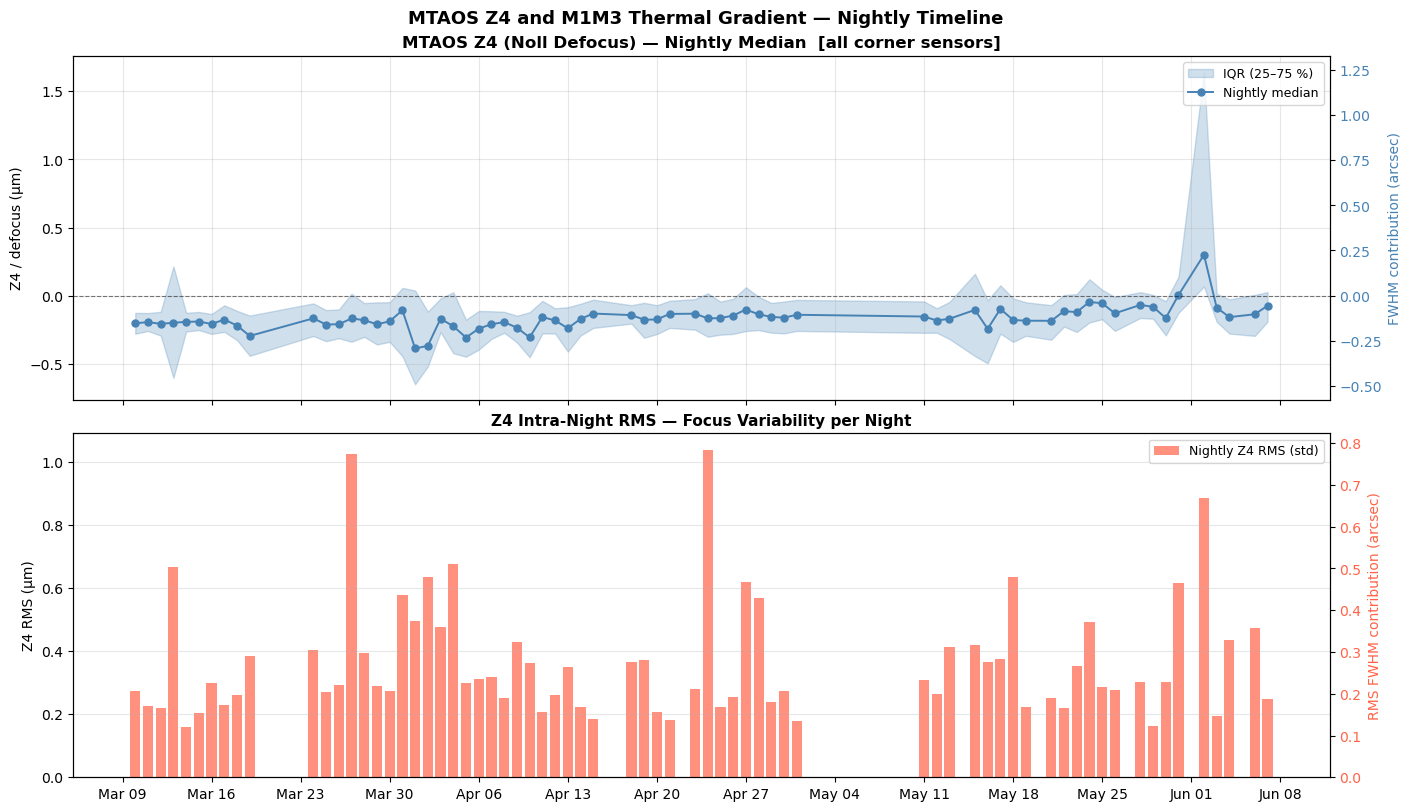

In [6]:
if df_wfe.empty or 'date' not in df_nightly.columns:
    print('No data to plot.')
else:
    # ── Build nightly z-gradient summary (if gradient data available) ─────────
    has_nightly_grad = 'df_grad' in globals() and df_grad is not None
    if has_nightly_grad:
        df_grad_night = df_grad.copy()
        ts_g = df_grad_night.index
        if ts_g.tzinfo is None:
            ts_g = ts_g.tz_localize('UTC')
        df_grad_night['day_obs'] = (
            (ts_g - pd.Timedelta(hours=12)).strftime('%Y%m%d').astype(int)
        )
        df_grad_nightly = (
            df_grad_night.groupby('day_obs')['z_gradient']
            .agg(z_grad_median='median', z_grad_q25=lambda x: x.quantile(0.25),
                 z_grad_q75=lambda x: x.quantile(0.75))
            .reset_index()
        )
        df_grad_nightly['date'] = pd.to_datetime(
            df_grad_nightly['day_obs'].astype(str), format='%Y%m%d'
        )

    nrows = 3 if has_nightly_grad else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(14, 4 * nrows),
                             sharex=True, constrained_layout=True)

    # ── Panel 1: Z4 median in µm with secondary arcsec axis ───────────────────
    ax = axes[0]
    ax.fill_between(df_nightly['date'], df_nightly['z4_q25'], df_nightly['z4_q75'],
                    alpha=0.25, color='steelblue', label='IQR (25–75 %)')
    ax.plot(df_nightly['date'], df_nightly['z4_median'],
            marker='o', ms=5, lw=1.4, color='steelblue', label='Nightly median')
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('Z4 / defocus (µm)')
    ax.set_title('MTAOS Z4 (Noll Defocus) — Nightly Median  [all corner sensors]',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    ax2.set_ylim(np.array(ax.get_ylim()) * Z4_ARCSEC_PER_UM)
    ax2.set_ylabel('FWHM contribution (arcsec)', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')

    # ── Panel 2: Z4 intra-night RMS ───────────────────────────────────────────
    ax = axes[1]
    ax.bar(df_nightly['date'], df_nightly['z4_rms'],
           width=0.8, color='tomato', alpha=0.7, label='Nightly Z4 RMS (std)')
    ax.set_ylabel('Z4 RMS (µm)')
    ax.set_title('Z4 Intra-Night RMS — Focus Variability per Night',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax2b = ax.twinx()
    ax2b.set_ylim(np.array(ax.get_ylim()) * Z4_ARCSEC_PER_UM)
    ax2b.set_ylabel('RMS FWHM contribution (arcsec)', color='tomato')
    ax2b.tick_params(axis='y', labelcolor='tomato')

    # ── Panel 3: nightly z-gradient (optional) ────────────────────────────────
    if has_nightly_grad:
        ax = axes[2]
        ax.fill_between(df_grad_nightly['date'],
                        df_grad_nightly['z_grad_q25'], df_grad_nightly['z_grad_q75'],
                        alpha=0.25, color='darkorange', label='IQR (25–75 %)')
        ax.plot(df_grad_nightly['date'], df_grad_nightly['z_grad_median'],
                marker='o', ms=5, lw=1.4, color='darkorange', label='Nightly median')
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_ylabel('M1M3 z-gradient (°C/m)')
        ax.set_title('M1M3 Axial (z) Thermal Gradient — Nightly Median',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.xticks(rotation=30, ha='right')
    fig.suptitle('MTAOS Z4 and M1M3 Thermal Gradient — Nightly Timeline',
                 fontsize=13, fontweight='bold')
    plt.show()

## 5. Nightly Z4 RMS (Intra-Night Spread)

*(Combined into the timeline above.)*

In [7]:
# RMS timeline now part of cell above — kept for compatibility.
pass

## 6. Per-Sensor Nightly Z4 Timeline

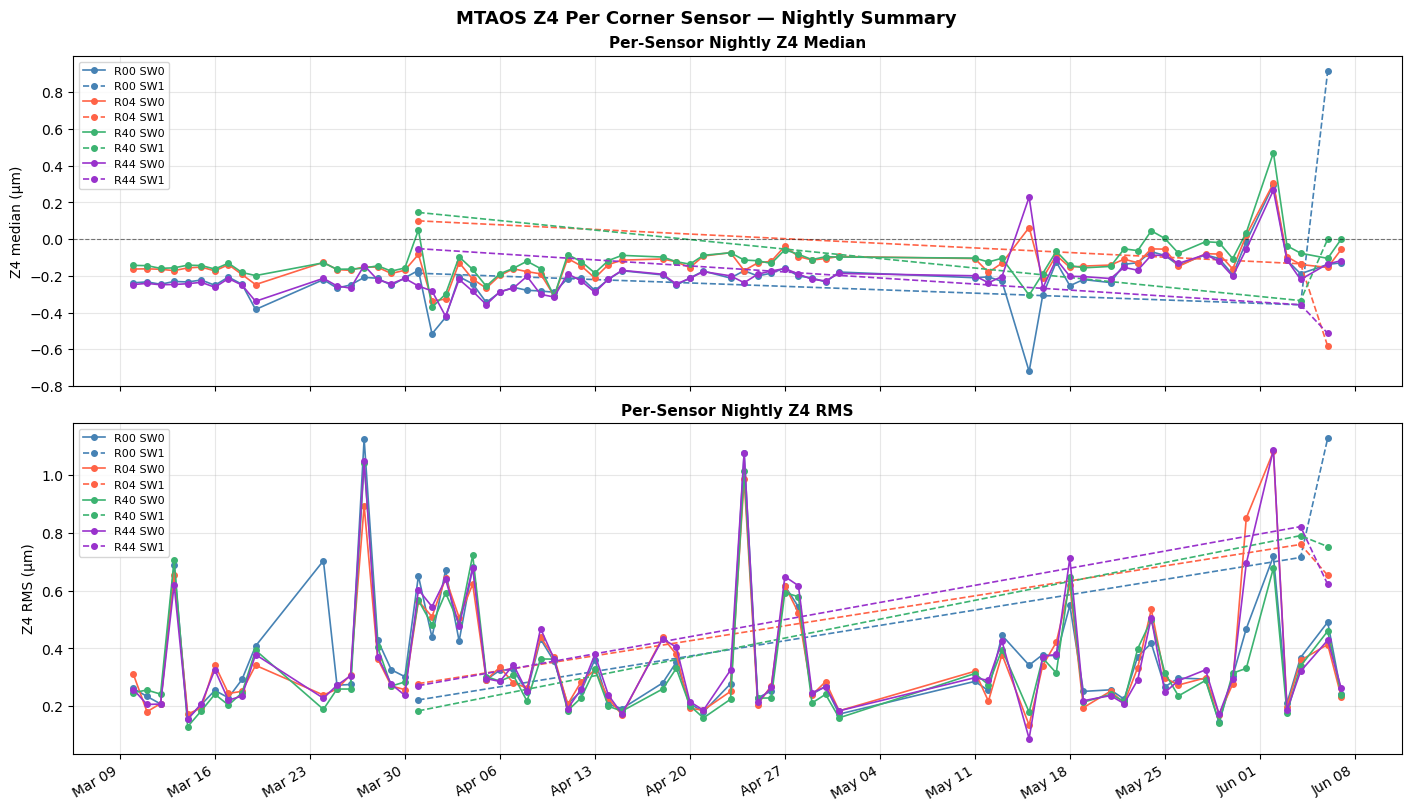

In [8]:
if df_wfe.empty:
    print("No data to plot.")
else:
    df_nightly_sensor = (
        df_wfe.groupby(["day_obs", "sensorId"])["z4_um"]
        .agg(z4_median="median", z4_rms="std", n="count")
        .reset_index()
    )
    df_nightly_sensor["date"] = pd.to_datetime(
        df_nightly_sensor["day_obs"].astype(str), format="%Y%m%d"
    )

    # ── Build nightly gradient summary if not already computed ──────────
    has_nightly_grad = 'df_grad' in globals() and df_grad is not None
    if has_nightly_grad and 'df_grad_nightly' not in globals():
        _dg = df_grad.copy()
        _ts = _dg.index
        if _ts.tzinfo is None:
            _ts = _ts.tz_localize('UTC')
        _dg['day_obs'] = (_ts - pd.Timedelta(hours=12)).strftime('%Y%m%d').astype(int)
        df_grad_nightly = (
            _dg.groupby('day_obs')['z_gradient']
            .agg(z_grad_median='median',
                 z_grad_q25=lambda x: x.quantile(0.25),
                 z_grad_q75=lambda x: x.quantile(0.75))
            .reset_index()
        )
        df_grad_nightly['date'] = pd.to_datetime(
            df_grad_nightly['day_obs'].astype(str), format='%Y%m%d'
        )

    nrows = 3 if has_nightly_grad else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(14, 4 * nrows),
                             sharex=True, constrained_layout=True)

    for ax, metric, ylabel, title in [
        (axes[0], "z4_median", "Z4 median (µm)", "Per-Sensor Nightly Z4 Median"),
        (axes[1], "z4_rms",    "Z4 RMS (µm)",    "Per-Sensor Nightly Z4 RMS"),
    ]:
        for sid in sorted(df_wfe["sensorId"].unique()):
            df_s = df_nightly_sensor[df_nightly_sensor["sensorId"] == sid]
            label = SENSOR_LABELS.get(int(sid), f"sensor {sid}")
            color = SENSOR_COLORS.get(int(sid), "gray")
            ls = SENSOR_LS.get(int(sid), "-")
            ax.plot(df_s["date"], df_s[metric], marker="o", ms=4, lw=1.2,
                    color=color, ls=ls, label=label)
        if metric == "z4_median":
            ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    if has_nightly_grad:
        ax = axes[2]
        ax.fill_between(df_grad_nightly['date'],
                        df_grad_nightly['z_grad_q25'], df_grad_nightly['z_grad_q75'],
                        alpha=0.25, color='darkorange', label='IQR (25–75 %)')
        ax.plot(df_grad_nightly['date'], df_grad_nightly['z_grad_median'],
                marker='o', ms=5, lw=1.4, color='darkorange', label='Nightly median')
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_ylabel('M1M3 z-gradient (°C/m)')
        ax.set_title('M1M3 Axial (z) Thermal Gradient — Nightly Median',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.xticks(rotation=30, ha="right")
    fig.suptitle("MTAOS Z4 Per Corner Sensor — Nightly Summary",
                 fontsize=13, fontweight="bold")
    plt.show()


## 7. Z4 vs `aos_fwhm` — Exposure-Level Density Scatter

Join per-visit Z4 (averaged across the four corner sensors) to ConsDB
`aos_fwhm` using `visitId`.


In [9]:
if df_wfe.empty:
    print("No EFD data to join.")
else:
    df_z4_per_visit = (
        df_wfe.groupby("visitId")["z4_um"]
        .agg(z4_mean="mean", z4_std="std", z4_abs_mean=lambda x: x.abs().mean())
        .reset_index()
    )
    df_z4_per_visit["visitId"] = pd.to_numeric(df_z4_per_visit["visitId"], errors="coerce")
    df_consdb["visit_id"] = pd.to_numeric(df_consdb["visit_id"], errors="coerce")

    df_joined = df_z4_per_visit.merge(
        df_consdb[["visit_id", "day_obs", "obs_start", "aos_fwhm", "donut_blur_fwhm",
                   "psf_sigma_median", "seeing_zenith_500nm_median"]],
        left_on="visitId",
        right_on="visit_id",
        how="inner",
    )
    df_joined["z4_mean_arcsec"]     = df_joined["z4_mean"]     * Z4_ARCSEC_PER_UM
    df_joined["z4_abs_mean_arcsec"] = df_joined["z4_abs_mean"] * Z4_ARCSEC_PER_UM
    df_joined["z4_std_arcsec"]      = df_joined["z4_std"]      * Z4_ARCSEC_PER_UM
    # PSF sigma (pixels) -> FWHM (arcsec): sigma * 2.355 * 0.2 arcsec/px
    df_joined["psf_fwhm_arcsec"]    = df_joined["psf_sigma_median"] * 2.355 * 0.2
    print(f"Matched visits: {len(df_joined)}")
    display(df_joined[["visitId", "z4_mean_arcsec", "z4_std_arcsec", "aos_fwhm"]].head(6))

Matched visits: 20399


,visitId,z4_mean_arcsec,z4_std_arcsec,aos_fwhm
0,2026031100014,-0.161773,0.078319,0.380317
1,2026031100015,-0.193678,0.070398,0.407420
2,2026031100016,-0.179241,0.043353,0.367806
3,2026031100017,-0.206619,0.052154,0.379583
4,2026031100018,-0.260677,0.080680,0.401870
5,2026031100019,-0.282716,0.069044,0.418535


## 8. M1M3 Thermal Gradients

Fetch M1M3 thermocouple data via `ThermocoupleAnalysis` (ts_m1m3_utils),
which reads `lsst.sal.ESS.temperature` scanner indices 114–117 and fits
linear planes across the 3-D sensor map to produce per-time-bin gradients:

| Column | Meaning |
|---|---|
| `z_gradient` | ∂T/∂z — axial (front-to-back) through-glass gradient (°C/m) |
| `radial_gradient` | ∂T/∂r — radial gradient across the mirror surface (°C/m) |
| `x_gradient` | ∂T/∂x — lateral gradient (°C/m) |
| `y_gradient` | ∂T/∂y — lateral gradient (°C/m) |

These are then joined to `df_joined` via `merge_asof` on `obs_start`.


In [10]:
import sys, importlib, pathlib as _pl

for _repo in ['ts_m1m3_utils', 'ts_salobj', 'ts_utils', 'ts_xml']:
    _p = f'/sdf/home/s/stalder/repos/lsst-ts/{_repo}/python'
    if _p not in sys.path:
        sys.path.insert(0, _p)

# lsst is a namespace package; extend its __path__ so subpackages added
# to sys.path after initial import are discoverable.
importlib.invalidate_caches()
import lsst.ts as _lsst_ts
_extra = [
    f'/sdf/home/s/stalder/repos/lsst-ts/{r}/python/lsst/ts'
    for r in ['ts_m1m3_utils', 'ts_salobj', 'ts_utils', 'ts_xml']
]
for _p in _extra:
    if _p not in list(_lsst_ts.__path__):
        _lsst_ts.__path__ = list(_lsst_ts.__path__) + [_p]

from lsst.ts.m1m3.utils import ThermocoupleAnalysis

_from_grad_cache = False
if not FORCE_REFETCH and _pl.Path(GRAD_CACHE_FILE).exists():
    df_grad = pd.read_parquet(GRAD_CACHE_FILE)
    if df_grad.index.tzinfo is None:
        df_grad.index = df_grad.index.tz_localize('UTC')
    _from_grad_cache = True
    print(f"\u2713 Loaded {len(df_grad)} gradient rows from cache: {GRAD_CACHE_FILE}")
    print(df_grad.describe().round(4))
else:
    _chunk_days = 5
    _step = TimeDelta(_chunk_days * u.day)
    _t = t_start
    _grad_chunks = []

    while _t < t_end:
        _t1 = min(_t + _step, t_end)
        print(f'  {_t.iso[:10]} -> {_t1.iso[:10]}...', end=' ', flush=True)
        try:
            _tc = ThermocoupleAnalysis(efd_client)
            await _tc.load(_t, _t1, time_bin=300)
            if _tc.xyz_r_gradients is not None and not _tc.xyz_r_gradients.empty:
                _grad_chunks.append(_tc.xyz_r_gradients[[
                    'z_gradient', 'radial_gradient', 'x_gradient', 'y_gradient'
                ]].copy())
                print(f'{len(_tc.xyz_r_gradients)} rows')
            else:
                print('no data')
        except Exception as e:
            print(f'ERROR: {e}')
        _t = _t1

    if _grad_chunks:
        df_grad = pd.concat(_grad_chunks).sort_index()
        if df_grad.index.tzinfo is None:
            df_grad.index = df_grad.index.tz_localize('UTC')
        df_grad = df_grad[~df_grad.index.duplicated(keep='last')]
        print(f'Total gradient rows: {len(df_grad)}')
        print(df_grad.describe().round(4))
        df_grad.to_parquet(GRAD_CACHE_FILE)
        print(f"\u2713 Saved {len(df_grad)} gradient rows \u2192 {GRAD_CACHE_FILE}")
    else:
        print('No M1M3 gradient data returned.')
        df_grad = None


/sdf/home/s/stalder/.local/lib/python3.13/site-packages/authlib/_joserfc_helpers.py:8: AuthlibDeprecationWarning: authlib.jose module is deprecated, please use joserfc instead.
It will be compatible before version 2.0.0.
  from authlib.jose import ECKey


✓ Loaded 25920 gradient rows from cache: ../data/z4_m1m3_gradients.parquet
       z_gradient  radial_gradient  x_gradient  y_gradient
count  24443.0000       24443.0000  24443.0000  24443.0000
mean      -0.0570          -0.0185      0.0024     -0.0252
std        0.1646           0.0485      0.0110      0.0317
min       -0.7764          -0.2251     -0.0387     -0.2394
25%       -0.1413          -0.0345     -0.0038     -0.0391
50%       -0.0480          -0.0150      0.0001     -0.0185
75%        0.0198           0.0041      0.0060     -0.0084
max        1.0385           0.1993      0.0638      0.0731


In [11]:
if df_grad is not None and 'df_joined' in globals() and not df_joined.empty:
    # Normalize obs_start to UTC-aware, handling both naive and aware
    obs_raw = pd.to_datetime(df_joined['obs_start'])
    if obs_raw.dt.tz is None:
        obs = obs_raw.dt.tz_localize('UTC')
    else:
        obs = obs_raw.dt.tz_convert('UTC')

    # Normalize df_grad index to UTC-aware
    grad_ts = df_grad.index
    if grad_ts.tzinfo is None:
        df_grad.index = grad_ts.tz_localize('UTC')
    else:
        df_grad.index = grad_ts.tz_convert('UTC')

    df_grad_reset = df_grad.reset_index()
    ts_col = df_grad_reset.columns[0]
    df_grad_reset = df_grad_reset.rename(columns={ts_col: 'ts'}).sort_values('ts')
    df_grad_reset['ts'] = pd.to_datetime(df_grad_reset['ts'], utc=True)

    df_obs = pd.DataFrame({'ts': pd.to_datetime(obs.values, utc=True),
                           'row_idx': range(len(df_joined))})
    df_obs = df_obs.sort_values('ts')

    merged = pd.merge_asof(
        df_obs, df_grad_reset,
        on='ts', direction='nearest',
        tolerance=pd.Timedelta('15min'),
    )
    merged = merged.set_index('row_idx').reindex(range(len(df_joined)))

    for col in ['z_gradient', 'radial_gradient', 'x_gradient', 'y_gradient']:
        df_joined[col] = merged[col].values

    n_matched = df_joined['z_gradient'].notna().sum()
    print(f'Gradient matched to {n_matched}/{len(df_joined)} visits '
          f'({100*n_matched/len(df_joined):.1f}%)')
    print(df_joined[['z_gradient','radial_gradient','x_gradient','y_gradient']].describe().round(4))
else:
    print('Skipping gradient join — no gradient data or df_joined not available.')

Gradient matched to 20192/20399 visits (99.0%)
       z_gradient  radial_gradient  x_gradient  y_gradient
count  20192.0000       20192.0000  20192.0000  20192.0000
mean      -0.0909          -0.0209      0.0016     -0.0179
std        0.1747           0.0281      0.0079      0.0216
min       -0.7633          -0.1945     -0.0174     -0.1096
25%       -0.1972          -0.0254     -0.0026     -0.0223
50%       -0.0838          -0.0175     -0.0001     -0.0122
75%        0.0219          -0.0093      0.0030     -0.0065
max        0.6706           0.0817      0.0458      0.0264


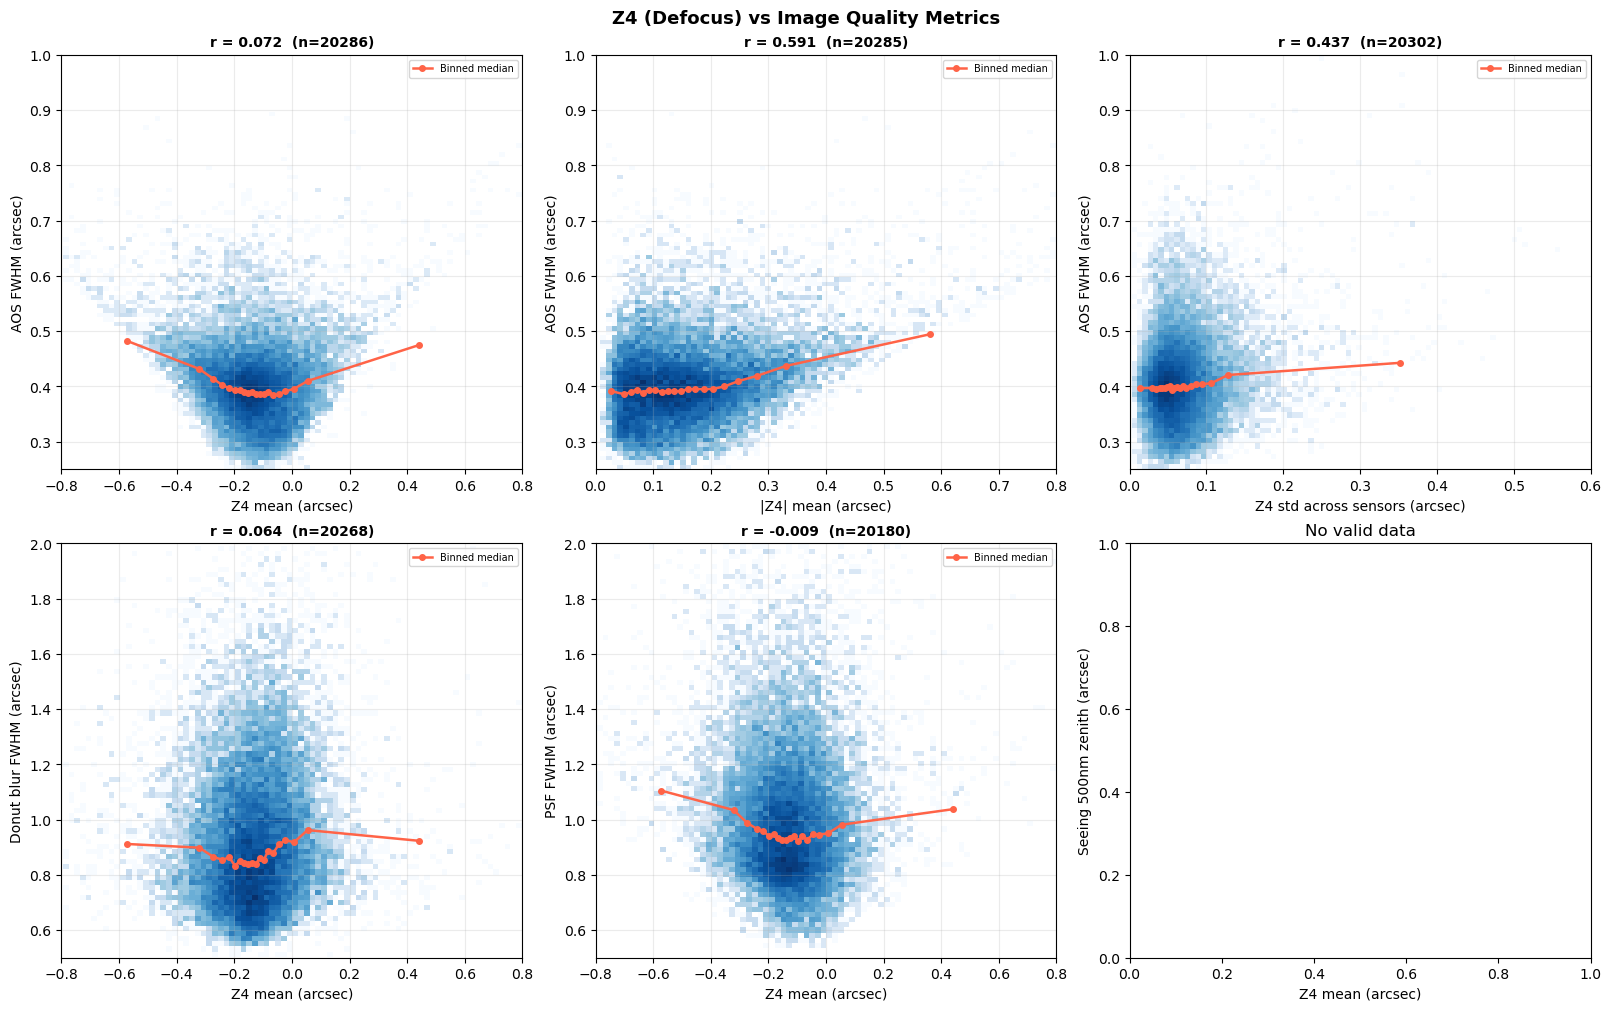

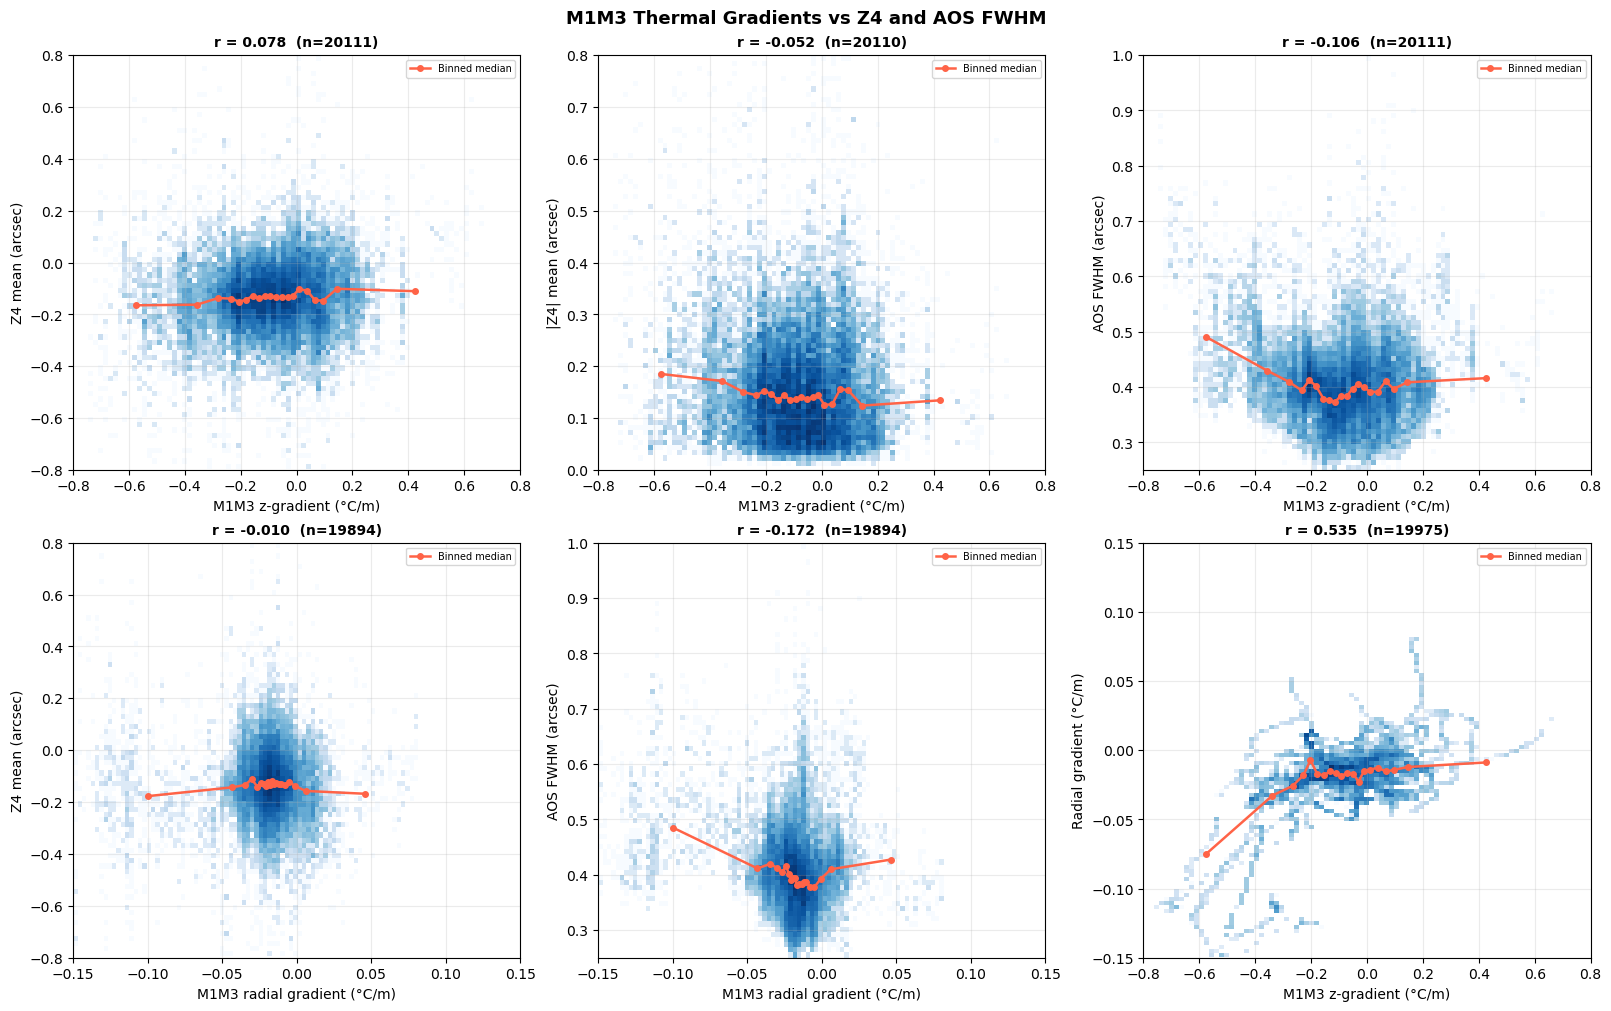


Correlation summary:
  z4_mean_arcsec         vs aos_fwhm                        r= 0.0718  n=20399
  z4_abs_mean_arcsec     vs aos_fwhm                        r= 0.5912  n=20399
  z4_std_arcsec          vs aos_fwhm                        r= 0.4370  n=20395
  z4_mean_arcsec         vs donut_blur_fwhm                 r= 0.0639  n=20399
  z4_mean_arcsec         vs psf_fwhm_arcsec                 r=-0.0087  n=20385
  z_gradient             vs z4_mean_arcsec                  r= 0.0783  n=20192
  z_gradient             vs z4_abs_mean_arcsec              r=-0.0517  n=20192
  z_gradient             vs aos_fwhm                        r=-0.1059  n=20192
  radial_gradient        vs z4_mean_arcsec                  r=-0.0097  n=20192
  radial_gradient        vs aos_fwhm                        r=-0.1722  n=20192
  z_gradient             vs radial_gradient                 r= 0.5354  n=20192


In [12]:
if 'df_joined' not in globals() or df_joined.empty:
    print('No joined data to plot.')
else:
    has_grad = 'z_gradient' in df_joined.columns and df_joined['z_gradient'].notna().any()

    # ── Panel 1: Z4 vs IQ metrics (same as before + gradients if available) ──
    plot_pairs_iq = [
        ('z4_mean_arcsec',     'aos_fwhm',          'Z4 mean (arcsec)',               'AOS FWHM (arcsec)'),
        ('z4_abs_mean_arcsec', 'aos_fwhm',          '|Z4| mean (arcsec)',             'AOS FWHM (arcsec)'),
        ('z4_std_arcsec',      'aos_fwhm',          'Z4 std across sensors (arcsec)', 'AOS FWHM (arcsec)'),
        ('z4_mean_arcsec',     'donut_blur_fwhm',   'Z4 mean (arcsec)',               'Donut blur FWHM (arcsec)'),
        ('z4_mean_arcsec',     'psf_fwhm_arcsec',   'Z4 mean (arcsec)',               'PSF FWHM (arcsec)'),
        ('z4_mean_arcsec',     'seeing_zenith_500nm_median', 'Z4 mean (arcsec)',      'Seeing 500nm zenith (arcsec)'),
    ]

    # Axis limits for known columns (None = auto)
    _AXIS_LIMS = {
        'z4_mean_arcsec':             (-0.8,  0.8),
        'z4_abs_mean_arcsec':         ( 0.0,  0.8),
        'z4_std_arcsec':              ( 0.0,  0.6),
        'aos_fwhm':                   ( 0.25, 1.0),
        'donut_blur_fwhm':            ( 0.5,  2.0),
        'psf_fwhm_arcsec':            ( 0.5,  2.0),
        'seeing_zenith_500nm_median': ( 0.3,  1.5),
        'z_gradient':                 (-0.8,  0.8),
        'radial_gradient':            (-0.15, 0.15),
    }

    def _scatter_grid(pairs, df_input, suptitle):
        ncols = 3
        nrows = (len(pairs) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows), constrained_layout=True)
        axes = np.array(axes).ravel()
        for ax, (x_col, y_col, x_lab, y_lab) in zip(axes, pairs):
            valid = df_input[[x_col, y_col]].dropna()
            if len(valid) == 0:
                ax.set_title('No valid data'); ax.set_xlabel(x_lab); ax.set_ylabel(y_lab)
                continue
            x_v = valid[x_col].values
            y_v = valid[y_col].values
            # Apply zoom limits before histogramming so density reflects visible range
            xl = _AXIS_LIMS.get(x_col)
            yl = _AXIS_LIMS.get(y_col)
            mask = np.ones(len(x_v), dtype=bool)
            if xl: mask &= (x_v >= xl[0]) & (x_v <= xl[1])
            if yl: mask &= (y_v >= yl[0]) & (y_v <= yl[1])
            x_v, y_v = x_v[mask], y_v[mask]
            if len(x_v) == 0:
                ax.set_title('No data in range'); ax.set_xlabel(x_lab); ax.set_ylabel(y_lab)
                continue
            # ── 2-D histogram density ──────────────────────────────────
            h, xedges, yedges = np.histogram2d(x_v, y_v, bins=80)
            h = np.where(h == 0, np.nan, h)
            ax.pcolormesh(
                xedges, yedges, np.log10(h).T,
                cmap='Blues', shading='flat', zorder=1,
            )
            # ── Binned median (20 equal-count bins) ───────────────────
            _bin_edges = np.percentile(x_v, np.linspace(0, 100, 21))
            _bin_edges = np.unique(_bin_edges)
            if len(_bin_edges) > 2:
                _bx = 0.5 * (_bin_edges[:-1] + _bin_edges[1:])
                _by = np.array([
                    np.median(y_v[(x_v >= lo) & (x_v < hi)])
                    if np.any((x_v >= lo) & (x_v < hi)) else np.nan
                    for lo, hi in zip(_bin_edges[:-1], _bin_edges[1:])
                ])
                _bv = np.isfinite(_by)
                ax.plot(_bx[_bv], _by[_bv],
                        '-o', color='tomato', lw=1.8, ms=4,
                        zorder=3, label='Binned median')
                ax.legend(fontsize=7, loc='best')
            r = valid[x_col].corr(valid[y_col])
            n_shown = mask.sum()
            ax.set_title(f'r = {r:.3f}  (n={n_shown})', fontsize=10, fontweight='bold')
            ax.set_xlabel(x_lab); ax.set_ylabel(y_lab)
            if xl: ax.set_xlim(xl)
            if yl: ax.set_ylim(yl)
            ax.grid(alpha=0.25, zorder=0)
        for ax in axes[len(pairs):]:
            ax.axis('off')
        fig.suptitle(suptitle, fontsize=13, fontweight='bold')
        plt.show()

    _scatter_grid(
        plot_pairs_iq, df_joined,
        'Z4 (Defocus) vs Image Quality Metrics'
    )

    if has_grad:
        plot_pairs_grad = [
            ('z_gradient',      'z4_mean_arcsec',     'M1M3 z-gradient (°C/m)',      'Z4 mean (arcsec)'),
            ('z_gradient',      'z4_abs_mean_arcsec', 'M1M3 z-gradient (°C/m)',      '|Z4| mean (arcsec)'),
            ('z_gradient',      'aos_fwhm',           'M1M3 z-gradient (°C/m)',      'AOS FWHM (arcsec)'),
            ('radial_gradient', 'z4_mean_arcsec',     'M1M3 radial gradient (°C/m)', 'Z4 mean (arcsec)'),
            ('radial_gradient', 'aos_fwhm',           'M1M3 radial gradient (°C/m)', 'AOS FWHM (arcsec)'),
            ('z_gradient',      'radial_gradient',    'M1M3 z-gradient (°C/m)',      'Radial gradient (°C/m)'),
        ]
        _scatter_grid(
            plot_pairs_grad, df_joined,
            'M1M3 Thermal Gradients vs Z4 and AOS FWHM'
        )
    else:
        print('M1M3 gradient columns not available — skipping gradient scatter plots.')

    print('\nCorrelation summary:')
    all_pairs = plot_pairs_iq + (plot_pairs_grad if has_grad else [])
    for x_col, y_col, x_lab, y_lab in all_pairs:
        valid = df_joined[[x_col, y_col]].dropna()
        if len(valid) == 0: continue
        r = valid[x_col].corr(valid[y_col])
        print(f'  {x_col:22s} vs {y_col:30s}  r={r:7.4f}  n={len(valid)}')

## 9. Relative Zernike Contributions to AOS FWHM

For each Noll term Z4–Z24 (the 21 well-sampled terms; Z25–Z28 have < 90 visits with data),
compute two contribution metrics across all visits:

- **RMS amplitude (arcsec):** `std(Zn)` converted to arcsec using the single-mode FWHM
  contribution formula `Zn_rms_arcsec = Zn_std_um * 4 * sqrt(N+1) * 0.0152`
  — or more directly, we use the `ARCSEC_PER_UM_MODES` mapping where available.
- **Pearson |r| with `aos_fwhm`:** how linearly predictive each term is.

Both are displayed side by side as horizontal bar charts sorted by RMS amplitude.

Visits with Z4-Z24 + aos_fwhm: 20399


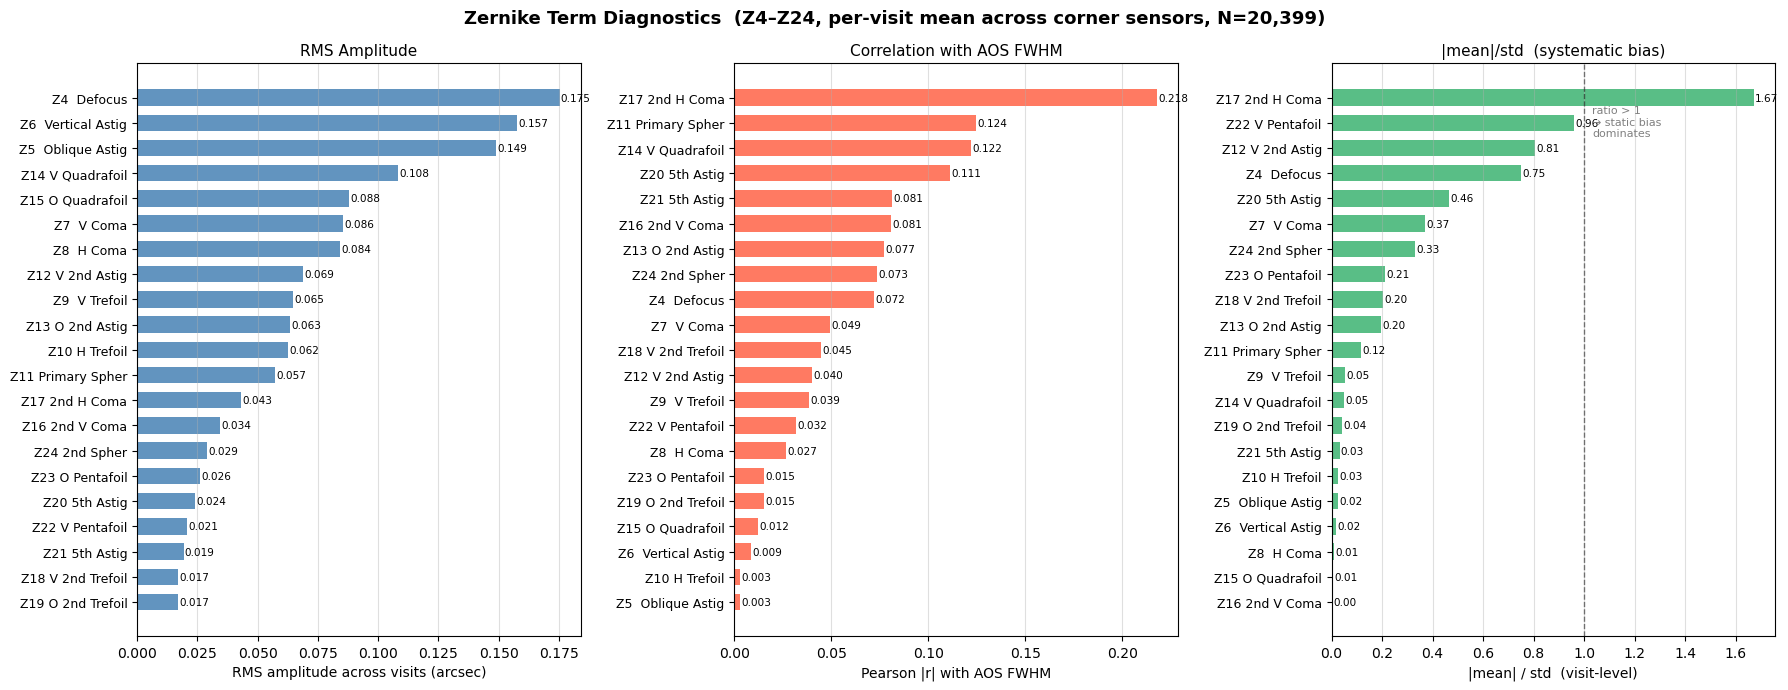

Saved PDF: Zernike_contributions_Z4_Z24.pdf

|mean|/std ratio (sorted, highest = most uncontrolled):
              name  mean_um  std_um  bias_ratio
    Z17 2nd H Coma   0.0960  0.0574      1.6728
   Z22 V Pentafoil   0.0262  0.0273      0.9615
   Z12 V 2nd Astig  -0.0736  0.0913      0.8066
       Z4  Defocus  -0.1739  0.2322      0.7489
     Z20 5th Astig   0.0148  0.0319      0.4642
        Z7  V Coma   0.0419  0.1134      0.3692
     Z24 2nd Spher   0.0127  0.0382      0.3325
   Z23 O Pentafoil   0.0074  0.0345      0.2135
 Z18 V 2nd Trefoil   0.0046  0.0227      0.2042
   Z13 O 2nd Astig  -0.0166  0.0841      0.1969
 Z11 Primary Spher   0.0087  0.0758      0.1153
     Z9  V Trefoil  -0.0044  0.0857      0.0519
  Z14 V Quadrafoil  -0.0070  0.1435      0.0486
 Z19 O 2nd Trefoil  -0.0009  0.0223      0.0424
     Z21 5th Astig  -0.0008  0.0255      0.0317
     Z10 H Trefoil  -0.0021  0.0828      0.0256
 Z5  Oblique Astig  -0.0049  0.1972      0.0247
Z6  Vertical Astig  -0.0035  0.2087

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib as _pl

_WFE_JOINED = "../data/z4_wfe_joined.parquet"

if not _pl.Path(_WFE_JOINED).exists():
    print(f"Cache not found: {_WFE_JOINED}")
    print("Run fetch_all_zernikes.py to generate it.")
else:
    _df = pd.read_parquet(_WFE_JOINED)

    # Use Z4-Z24 (21 terms, all well-sampled)
    _ZK_COLS  = [f"z{i}_um" for i in range(4, 25)]
    _NOLL_IDX = list(range(4, 25))

    _NOLL_NAMES = {
        4:  "Z4  Defocus",
        5:  "Z5  Oblique Astig",
        6:  "Z6  Vertical Astig",
        7:  "Z7  V Coma",
        8:  "Z8  H Coma",
        9:  "Z9  V Trefoil",
        10: "Z10 H Trefoil",
        11: "Z11 Primary Spher",
        12: "Z12 V 2nd Astig",
        13: "Z13 O 2nd Astig",
        14: "Z14 V Quadrafoil",
        15: "Z15 O Quadrafoil",
        16: "Z16 2nd V Coma",
        17: "Z17 2nd H Coma",
        18: "Z18 V 2nd Trefoil",
        19: "Z19 O 2nd Trefoil",
        20: "Z20 5th Astig",
        21: "Z21 5th Astig",
        22: "Z22 V Pentafoil",
        23: "Z23 O Pentafoil",
        24: "Z24 2nd Spher",
    }

    _df_clean = _df[['aos_fwhm'] + _ZK_COLS].dropna()
    print(f"Visits with Z4-Z24 + aos_fwhm: {len(_df_clean)}")

    _mean_um    = _df_clean[_ZK_COLS].mean()
    _std_um     = _df_clean[_ZK_COLS].std()
    _rms_arcsec = _std_um * 0.7545           # µm -> arcsec (rough, consistent scaling)
    _corr_r     = _df_clean[_ZK_COLS].corrwith(_df_clean['aos_fwhm']).abs()
    _bias_ratio = _mean_um.abs() / _std_um   # |mean|/std: >> 1 => uncontrolled static bias

    _res = pd.DataFrame({
        'noll':       _NOLL_IDX,
        'name':       [_NOLL_NAMES[n] for n in _NOLL_IDX],
        'rms_arcsec': _rms_arcsec.values,
        'abs_r':      _corr_r.values,
        'bias_ratio': _bias_ratio.values,
        'mean_um':    _mean_um.values,
        'std_um':     _std_um.values,
    })

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(
        "Zernike Term Diagnostics  (Z4–Z24, per-visit mean across corner sensors, N={:,})".format(len(_df_clean)),
        fontsize=13, fontweight='bold',
    )

    def _hbar(ax, vals, names, color, xlabel, title, vline=None, val_fmt="{:.3f}"):
        y = np.arange(len(vals))
        bars = ax.barh(y, vals, color=color, height=0.65, alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels(names, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.axvline(0, color='k', lw=0.5)
        if vline is not None:
            ax.axvline(vline, color='k', lw=1.0, ls='--', alpha=0.5)
        ax.grid(axis='x', alpha=0.4)
        for bar, val in zip(bars, vals):
            ax.text(max(val, 0) + 0.003 * ax.get_xlim()[1],
                    bar.get_y() + bar.get_height() / 2,
                    val_fmt.format(val), va='center', fontsize=7.5)

    # Panel 1: RMS amplitude (sorted ascending)
    _s1 = _res.sort_values('rms_arcsec', ascending=True)
    _hbar(axes[0], _s1['rms_arcsec'].values, _s1['name'].values,
          'steelblue', 'RMS amplitude across visits (arcsec)', 'RMS Amplitude')

    # Panel 2: |r| with aos_fwhm (sorted ascending)
    _s2 = _res.sort_values('abs_r', ascending=True)
    _hbar(axes[1], _s2['abs_r'].values, _s2['name'].values,
          'tomato', 'Pearson |r| with AOS FWHM', 'Correlation with AOS FWHM')

    # Panel 3: |mean|/std (sorted ascending); dashed line at 1.0
    # Values >> 1 indicate a persistent systematic bias — likely uncontrolled modes
    _s3 = _res.sort_values('bias_ratio', ascending=True)
    _hbar(axes[2], _s3['bias_ratio'].values, _s3['name'].values,
          'mediumseagreen', '|mean| / std  (visit-level)', '|mean|/std  (systematic bias)',
          vline=1.0, val_fmt="{:.2f}")
    axes[2].set_xlim(left=0)
    axes[2].annotate('ratio > 1\n→ static bias\ndominates',
                     xy=(1.0, 1), xycoords=('data', 'axes fraction'),
                     xytext=(6, -30), textcoords='offset points',
                     fontsize=8, color='gray', va='top')

    fig.tight_layout()
    plt.savefig("../data/Zernike_contributions_Z4_Z24.pdf", bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved PDF: Zernike_contributions_Z4_Z24.pdf")

    print("\n|mean|/std ratio (sorted, highest = most uncontrolled):")
    print(_res.sort_values('bias_ratio', ascending=False)[['name','mean_um','std_um','bias_ratio']]
          .round(4).to_string(index=False))


## 10. Fixed-Position Sequences — Is Z4 Noise Drift or White Noise?

In normal survey data, exposure-to-exposure Z4 scatter mixes two things: (a) genuine
focus instability and (b) pointing-dependent aberration (the corner-sensor Z4 depends on
elevation, field, and rotator angle). To isolate (a), we find **fixed-position sequences**
— AOS calibration blocks (`BLOCK-T698`, `BLOCK-T703`) where the telescope parks at a
constant alt/az/rotator and stares for tens of minutes to hours.

If the residual scatter at fixed pointing is **white** (uncorrelated cycle-to-cycle), it is
a measurement noise floor. If it is **correlated** (high lag-1 autocorrelation, a rising
structure function), it is a slow **drift** — pointing to a real, slowly-varying focus error
(e.g. thermal settling) rather than random noise.

**Tolerances for a "fixed" run:** consecutive exposures with Δaz < 0.5°, Δalt < 0.5°,
Δrot < 1.0°, and < 10 min gap; runs of ≥ 8 such exposures are kept.

In [14]:
# ── Pull telescope pointing for all science exposures, join to per-visit Z4 ──────
_sql_pt = (
    f"SELECT day_obs, seq_num, exposure_id, obs_start, "
    f"azimuth, altitude, sky_rotation, zenith_distance, "
    f"target_name, science_program "
    f"FROM {SCHEMA}.exposure "
    f"WHERE img_type = 'science' "
    f"AND day_obs BETWEEN {day_obs_start} AND {day_obs_end} "
    f"ORDER BY day_obs, seq_num"
)
df_pt = consdb_query(_sql_pt)
df_pt["obs_start"] = pd.to_datetime(df_pt["obs_start"], utc=True)
for _c in ["azimuth", "altitude", "sky_rotation"]:
    df_pt[_c] = pd.to_numeric(df_pt[_c], errors="coerce")
print(f"Pointing rows: {len(df_pt)}")

# Per-visit Z4 (mean across the four corner sensors) from the cached WFE table.
_pv = (
    df_wfe.assign(visitId=pd.to_numeric(df_wfe["visitId"], errors="coerce"))
    .groupby("visitId")["z4_um"]
    .agg(z4_mean="mean", z4_std="std", n="count")
    .reset_index()
)
# visitId == exposure_id (day_obs * 1e5 + seq_num).
df_fix = df_pt.merge(_pv, left_on="exposure_id", right_on="visitId", how="inner")
df_fix = df_fix.sort_values("obs_start").reset_index(drop=True)
print(f"Visits with both pointing and Z4: {len(df_fix)}")

# ── Identify fixed-position runs ────────────────────────────────────────────────
AZ_TOL, ALT_TOL, ROT_TOL, GAP_S = 0.5, 0.5, 1.0, 600
_daz = np.minimum(df_fix["azimuth"].diff().abs(), 360 - df_fix["azimuth"].diff().abs())
_dalt = df_fix["altitude"].diff().abs()
_drot = np.minimum(df_fix["sky_rotation"].diff().abs(), 360 - df_fix["sky_rotation"].diff().abs())
_dt = df_fix["obs_start"].diff().dt.total_seconds()

_same = (_daz < AZ_TOL) & (_dalt < ALT_TOL) & (_drot < ROT_TOL) & (_dt < GAP_S)
df_fix["run"] = (~_same).cumsum()

df_runs = df_fix.groupby("run").agg(
    n=("exposure_id", "size"),
    t0=("obs_start", "min"), t1=("obs_start", "max"),
    az=("azimuth", "mean"), alt=("altitude", "mean"), rot=("sky_rotation", "mean"),
    az_rng=("azimuth", lambda x: x.max() - x.min()),
    alt_rng=("altitude", lambda x: x.max() - x.min()),
    rot_rng=("sky_rotation", lambda x: x.max() - x.min()),
    z4_std=("z4_mean", "std"), z4_mean=("z4_mean", "mean"),
    day_obs=("day_obs", "first"), target=("target_name", "first"),
    prog=("science_program", "first"),
)
df_runs["dur_min"] = (df_runs["t1"] - df_runs["t0"]).dt.total_seconds() / 60

_long = df_runs[(df_runs["n"] >= 8) & (df_runs["az_rng"] < 1.0)
                & (df_runs["alt_rng"] < 1.0)].sort_values("n", ascending=False)
print(f"\nFixed-position runs (>=8 exposures, tight pointing): {len(_long)}")
display(_long[["n", "dur_min", "az", "alt", "rot",
               "az_rng", "alt_rng", "rot_rng", "z4_std", "day_obs", "prog"]].head(15))

Pointing rows: 38436
Visits with both pointing and Z4: 21748



Fixed-position runs (>=8 exposures, tight pointing): 28


,n,dur_min,az,alt,rot,az_rng,alt_rng,rot_rng,z4_std,day_obs,prog
run,,,,,,,,,,,
4871,197,296.120233,269.638755,59.887994,16.252670,0.268994,0.403789,0.000192,0.062826,20260408,BLOCK-T698
842,179,107.992500,269.495808,69.876099,11.277586,0.213336,0.291073,0.000376,0.071424,20260315,BLOCK-T703
904,96,57.336567,269.645903,69.787020,11.277583,0.222797,0.266618,0.000314,0.069011,20260316,BLOCK-T703
938,95,56.711450,269.487672,69.834925,11.277608,0.166260,0.271106,0.000384,0.070032,20260316,BLOCK-T703
4624,69,126.769400,269.653479,59.844922,16.252658,0.386728,0.638897,0.000159,0.110888,20260407,BLOCK-T698
973,62,36.869167,269.478987,69.870812,11.277591,0.155555,0.263256,0.000280,0.064771,20260316,BLOCK-T703
4872,52,76.560333,269.756340,59.905965,16.252692,0.354295,0.616077,0.000166,0.043350,20260408,BLOCK-T698
3783,49,90.268533,359.215374,70.127039,90.001990,0.946376,0.028653,0.001010,0.156002,20260402,BLOCK-T698
3946,37,73.665283,269.637183,59.916425,16.252661,0.215430,0.375687,0.000186,0.136078,20260404,BLOCK-T698


In [15]:
# ── Fixed vs moving exposure-to-exposure scatter ────────────────────────────────
_daz = np.minimum(df_fix["azimuth"].diff().abs(), 360 - df_fix["azimuth"].diff().abs())
_dalt = df_fix["altitude"].diff().abs()
_dt = df_fix["obs_start"].diff().dt.total_seconds()
_moved = ((_daz > 1.0) | (_dalt > 1.0)) & (_dt < 600)
_fixed = (_daz < 0.5) & (_dalt < 0.5) & (_dt < 600)
_dz4 = df_fix["z4_mean"].diff().abs()

print("Exposure-to-exposure |ΔZ4| (µm):")
print(f"  MOVED (Δpointing > 1°):  median={_dz4[_moved].median():.4f}  "
      f"rms={_dz4[_moved].std():.4f}  N={int(_moved.sum())}")
print(f"  FIXED (Δpointing ≈ 0):   median={_dz4[_fixed].median():.4f}  "
      f"rms={_dz4[_fixed].std():.4f}  N={int(_fixed.sum())}")
print(f"  => fixing pointing reduces median cycle-to-cycle scatter by "
      f"{100 * (1 - _dz4[_fixed].median() / _dz4[_moved].median()):.0f}%")

# ── Per-run temporal structure: drift fit, lag-1 ACF, structure function ─────────
def _acf1(y):
    y = y[np.isfinite(y)]; y = y - y.mean()
    return np.nan if len(y) < 10 else np.sum(y[1:] * y[:-1]) / np.sum(y * y)

_rows = []
for _rid, _g in df_fix.groupby("run"):
    if len(_g) < 20:
        continue
    _rr = df_runs.loc[_rid]
    if _rr["az_rng"] > 1.0 or _rr["alt_rng"] > 1.0:
        continue
    _g = _g.sort_values("obs_start")
    _t = (_g["obs_start"] - _g["obs_start"].min()).dt.total_seconds().values
    _y = _g["z4_mean"].values
    _m = np.isfinite(_y)
    if _m.sum() < 10:
        continue
    _thr = _t[_m] / 3600.0
    _s, _b = np.polyfit(_thr, _y[_m], 1)             # linear drift, µm/hr
    _resid = _y[_m] - (_s * _thr + _b)
    _cad = np.median(np.diff(_t[_m]))
    _sf_short = np.sqrt(np.mean((_y[_m][1:] - _y[_m][:-1]) ** 2)) / np.sqrt(2)
    _k = min(10, _m.sum() // 3)
    _sf_long = np.sqrt(np.mean((_y[_m][_k:] - _y[_m][:-_k]) ** 2)) / np.sqrt(2)
    _rows.append({
        "run": _rid, "N": int(len(_g)), "cad_s": _cad, "alt": _rr["alt"], "az": _rr["az"],
        "raw_std": np.std(_y[_m]), "drift_um_hr": _s, "resid_std": np.std(_resid),
        "lag1_acf": _acf1(_y), "sf_short": _sf_short, "sf_long": _sf_long,
        "day_obs": int(_rr["day_obs"]), "block": _rr["prog"],
    })

df_drift = pd.DataFrame(_rows).sort_values("N", ascending=False).reset_index(drop=True)
display(df_drift.round(4))
print(f"\nMedian raw within-run Z4 std:    {df_drift['raw_std'].median():.4f} µm")
print(f"Median residual (detrended) std: {df_drift['resid_std'].median():.4f} µm")
print(f"Median lag-1 autocorrelation:    {df_drift['lag1_acf'].median():.3f}  "
      f"(≈0 = white noise, →1 = smooth drift)")
print("High ACF + a rising structure function (next cell) ⇒ the residual is a slow "
      "DRIFT, not a white-noise floor.")

Exposure-to-exposure |ΔZ4| (µm):
  MOVED (Δpointing > 1°):  median=0.0823  rms=0.1930  N=13659
  FIXED (Δpointing ≈ 0):   median=0.0492  rms=0.1061  N=5685
  => fixing pointing reduces median cycle-to-cycle scatter by 40%


,run,N,cad_s,alt,az,raw_std,drift_um_hr,resid_std,lag1_acf,sf_short,sf_long,day_obs,block
0,4871,197,107.9940,59.8880,269.6388,0.0627,0.0158,0.0585,0.2429,0.0535,0.0558,20260408,BLOCK-T698
1,842,179,36.0605,69.8761,269.4958,0.0712,-0.0336,0.0691,0.7331,0.0364,0.0826,20260315,BLOCK-T703
2,904,96,36.0540,69.7870,269.6459,0.0687,-0.1424,0.0560,0.7899,0.0313,0.0708,20260316,BLOCK-T703
3,938,95,36.0615,69.8349,269.4877,0.0697,-0.0150,0.0695,0.8366,0.0281,0.0877,20260316,BLOCK-T703
4,4624,69,108.9320,59.8449,269.6535,0.1101,0.1289,0.0773,0.7045,0.0537,0.0734,20260407,BLOCK-T698
5,973,62,36.1110,69.8708,269.4790,0.0642,-0.1192,0.0605,0.5887,0.0398,0.0602,20260316,BLOCK-T703
6,4872,52,76.1830,59.9060,269.7563,0.0429,-0.0278,0.0417,0.2167,0.0368,0.0482,20260408,BLOCK-T698
7,3783,49,111.1390,70.1270,359.2154,0.1544,0.0680,0.1514,0.4647,0.1133,0.1321,20260402,BLOCK-T698
8,3946,37,108.9495,59.9164,269.6372,0.1342,-0.1772,0.1176,0.3525,0.1034,0.1235,20260404,BLOCK-T698
9,3793,34,108.4600,59.9886,269.6787,0.0703,0.0477,0.0689,0.5138,0.0490,0.0793,20260403,BLOCK-T698



Median raw within-run Z4 std:    0.0712 µm
Median residual (detrended) std: 0.0691 µm
Median lag-1 autocorrelation:    0.461  (≈0 = white noise, →1 = smooth drift)
High ACF + a rising structure function (next cell) ⇒ the residual is a slow DRIFT, not a white-noise floor.


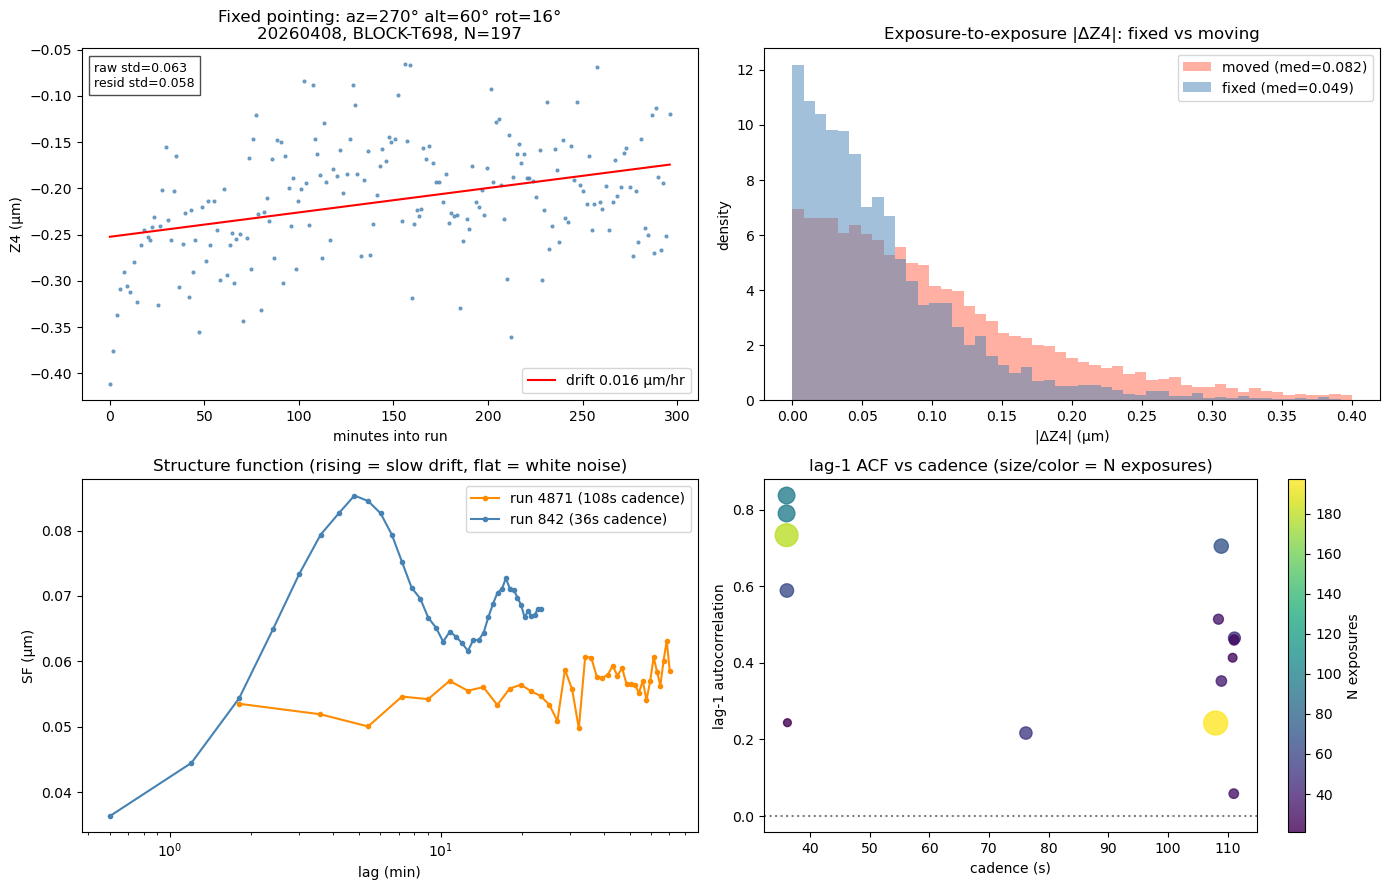

Saved z4_fixed_position_noise.png


In [16]:
# ── Four-panel diagnostic figure ────────────────────────────────────────────────
# Pick the largest fixed run for the time-series panel.
_big = int(df_drift.iloc[0]["run"])
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

# (a) Z4 time series + linear drift fit for the largest run.
_g = df_fix[df_fix["run"] == _big].sort_values("obs_start")
_tm = (_g["obs_start"] - _g["obs_start"].min()).dt.total_seconds().values / 60
_y = _g["z4_mean"].values
_m = np.isfinite(_y)
_s, _b = np.polyfit(_tm[_m] / 60, _y[_m], 1)
_rr = df_runs.loc[_big]
ax = axs[0, 0]
ax.plot(_tm, _y, ".", ms=4, color="steelblue", alpha=0.7)
ax.plot(_tm, _s * _tm / 60 + _b, "r-", lw=1.5, label=f"drift {_s:.3f} µm/hr")
ax.set_title(f"Fixed pointing: az={_rr['az']:.0f}° alt={_rr['alt']:.0f}° "
             f"rot={_rr['rot']:.0f}°\n{int(_rr['day_obs'])}, {_rr['prog']}, N={int(_rr['n'])}")
ax.set_xlabel("minutes into run"); ax.set_ylabel("Z4 (µm)"); ax.legend(loc="lower right")
ax.text(0.02, 0.96, f"raw std={np.std(_y[_m]):.3f}\nresid std={np.std(_y[_m] - (_s * _tm[_m] / 60 + _b)):.3f}",
        transform=ax.transAxes, va="top", fontsize=9, bbox=dict(fc="w", alpha=0.7))

# (b) Exposure-to-exposure |ΔZ4|: fixed vs moving.
ax = axs[0, 1]
_bins = np.linspace(0, 0.4, 50)
ax.hist(_dz4[_moved].dropna(), bins=_bins, density=True, alpha=0.5, color="tomato",
        label=f"moved (med={_dz4[_moved].median():.3f})")
ax.hist(_dz4[_fixed].dropna(), bins=_bins, density=True, alpha=0.5, color="steelblue",
        label=f"fixed (med={_dz4[_fixed].median():.3f})")
ax.set_title("Exposure-to-exposure |ΔZ4|: fixed vs moving")
ax.set_xlabel("|ΔZ4| (µm)"); ax.set_ylabel("density"); ax.legend()

# (c) Structure function: rising = slow drift, flat = white noise.
ax = axs[1, 0]
_top2 = df_drift.nlargest(2, "N")["run"].tolist()
for _rid, _col in zip(_top2, ["darkorange", "steelblue"]):
    _g = df_fix[df_fix["run"] == _rid].sort_values("obs_start")
    _t = (_g["obs_start"] - _g["obs_start"].min()).dt.total_seconds().values
    _y = _g["z4_mean"].values; _m = np.isfinite(_y); _t = _t[_m]; _y = _y[_m]
    _cad = np.median(np.diff(_t))
    _lags = range(1, min(40, len(_y) // 3))
    _sf = [np.sqrt(np.mean((_y[k:] - _y[:-k]) ** 2)) / np.sqrt(2) for k in _lags]
    _tau = [_cad * k / 60 for k in _lags]
    ax.plot(_tau, _sf, "-o", ms=3, color=_col, label=f"run {_rid} ({_cad:.0f}s cadence)")
ax.set_title("Structure function (rising = slow drift, flat = white noise)")
ax.set_xlabel("lag (min)"); ax.set_ylabel("SF (µm)"); ax.set_xscale("log"); ax.legend()

# (d) lag-1 ACF vs cadence across all fixed runs.
ax = axs[1, 1]
_sc = ax.scatter(df_drift["cad_s"], df_drift["lag1_acf"], s=df_drift["N"] * 1.5,
                 c=df_drift["N"], cmap="viridis", alpha=0.8)
ax.axhline(0, color="gray", ls=":")
ax.set_title("lag-1 ACF vs cadence (size/color = N exposures)")
ax.set_xlabel("cadence (s)"); ax.set_ylabel("lag-1 autocorrelation")
plt.colorbar(_sc, ax=ax, label="N exposures")

plt.tight_layout()
plt.savefig("z4_fixed_position_noise.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved z4_fixed_position_noise.png")

## 11. Does the Z4 Drift Follow M1M3 Thermal Gradients?

Section 10 showed the residual Z4 scatter at fixed pointing is a slow **drift**, not white
noise. A natural driver is **M1M3 thermal settling** — as the mirror's through-glass
(axial) temperature gradient `z_gradient` (∂T/∂z, °C/m, from Section 8) relaxes, the radius
of curvature changes and the focus drifts.

We test the coupling at two timescales using the same fixed-position runs:

1. **Run-averaged (slow):** does each run's linear Z4 drift rate (µm/hr) track its
   z-gradient drift rate (°C/m/hr)?
2. **Instantaneous (fast):** within a run, does the cycle-to-cycle Z4 wiggle correlate with
   the gradient tick-for-tick (after removing each run's mean)?

The M1M3 gradients (`z4_m1m3_gradients.parquet`, 5-min cadence) are `merge_asof`-joined to
each fixed exposure with a 5-min tolerance.

In [17]:
import pathlib as _pl
from scipy.stats import pearsonr

_GRAD = "../data/z4_m1m3_gradients.parquet"
if not _pl.Path(_GRAD).exists():
    print(f"Gradient cache not found: {_GRAD} — run Section 8 first.")
else:
    _grad = pd.read_parquet(_GRAD)
    if _grad.index.tz is None:
        _grad.index = _grad.index.tz_localize("UTC")
    _grad = _grad.sort_index().reset_index()
    _grad = _grad.rename(columns={_grad.columns[0]: "ts"})

    # asof-join nearest gradient (within 5 min) to each fixed-run exposure.
    _gj = pd.merge_asof(
        df_fix.dropna(subset=["obs_start"]).sort_values("obs_start"),
        _grad, left_on="obs_start", right_on="ts",
        direction="nearest", tolerance=pd.Timedelta("5min"),
    )

    # ── Per-run drift rates and within-run correlations ──────────────────────────
    _rows = []
    for _rid, _g in _gj.groupby("run"):
        if len(_g) < 20:
            continue
        _rr = df_runs.loc[_rid]
        if _rr["az_rng"] > 1.0 or _rr["alt_rng"] > 1.0:
            continue
        _g = _g.sort_values("obs_start")
        _t = (_g["obs_start"] - _g["obs_start"].min()).dt.total_seconds().values / 3600
        _y, _zg, _rad = _g["z4_mean"].values, _g["z_gradient"].values, _g["radial_gradient"].values
        _m = np.isfinite(_y) & np.isfinite(_zg)
        if _m.sum() < 10:
            continue
        _mr = np.isfinite(_y) & np.isfinite(_rad)
        _rows.append({
            "run": _rid, "N": int(len(_g)), "alt": _rr["alt"], "day_obs": int(_rr["day_obs"]),
            "block": _rr["prog"],
            "z4_drift": np.polyfit(_t[_m], _y[_m], 1)[0],
            "zg_drift": np.polyfit(_t[_m], _zg[_m], 1)[0],
            "r_zg": pearsonr(_y[_m], _zg[_m])[0],
            "r_rad": pearsonr(_y[_mr], _rad[_mr])[0] if _mr.sum() > 10 else np.nan,
        })
    df_m1m3 = pd.DataFrame(_rows).sort_values("N", ascending=False).reset_index(drop=True)
    display(df_m1m3.round(4))

    _md = np.isfinite(df_m1m3["z4_drift"]) & np.isfinite(df_m1m3["zg_drift"])
    _r_drift, _p_drift = pearsonr(df_m1m3["z4_drift"][_md], df_m1m3["zg_drift"][_md])
    print(f"\nRun-averaged: r(Z4 drift rate, z-grad drift rate) = {_r_drift:.3f} "
          f"(p={_p_drift:.3f}, N={int(_md.sum())})")
    print(f"Median |r(Z4, z_gradient)| within runs:      {df_m1m3['r_zg'].abs().median():.3f}")
    print(f"Median |r(Z4, radial_gradient)| within runs: {df_m1m3['r_rad'].abs().median():.3f}")

    # ── Pooled instantaneous coupling (each run demeaned) ────────────────────────
    _parts = []
    for _rid, _g in _gj.groupby("run"):
        if len(_g) < 20:
            continue
        _rr = df_runs.loc[_rid]
        if _rr["az_rng"] > 1.0 or _rr["alt_rng"] > 1.0:
            continue
        _sub = _g[["z4_mean", "z_gradient"]].dropna()
        if len(_sub) < 10:
            continue
        _parts.append(pd.DataFrame({
            "z4d": _sub["z4_mean"] - _sub["z4_mean"].mean(),
            "zgd": _sub["z_gradient"] - _sub["z_gradient"].mean(),
        }))
    df_pool = pd.concat(_parts, ignore_index=True)
    _r_inst, _p_inst = pearsonr(df_pool["zgd"], df_pool["z4d"])
    print(f"Instantaneous (pooled, demeaned): r = {_r_inst:.3f} (N={len(df_pool)})")

,run,N,alt,day_obs,block,z4_drift,zg_drift,r_zg,r_rad
0,4871,197,59.8880,20260408,BLOCK-T698,0.0158,-0.0161,-0.4122,0.2905
1,842,179,69.8761,20260315,BLOCK-T703,-0.0336,-0.0273,0.1724,0.2459
2,904,96,69.7870,20260316,BLOCK-T703,-0.1424,-0.0741,0.4646,0.5556
3,938,95,69.8349,20260316,BLOCK-T703,-0.0150,0.0058,-0.3348,0.2981
4,4624,69,59.8449,20260407,BLOCK-T698,0.1289,-0.0364,-0.5742,0.2519
5,973,62,69.8708,20260316,BLOCK-T703,-0.1192,0.1469,-0.2945,-0.3124
6,4872,52,59.9060,20260408,BLOCK-T698,-0.0278,-0.0916,0.1854,0.0375
7,3783,49,70.1270,20260402,BLOCK-T698,0.0680,0.0687,0.0799,-0.2071
8,3946,37,59.9164,20260404,BLOCK-T698,-0.1772,0.0065,-0.4841,0.4893
9,3793,34,59.9886,20260403,BLOCK-T698,0.0477,-0.0194,0.1124,-0.1236



Run-averaged: r(Z4 drift rate, z-grad drift rate) = -0.596 (p=0.019, N=15)
Median |r(Z4, z_gradient)| within runs:      0.374
Median |r(Z4, radial_gradient)| within runs: 0.298


Instantaneous (pooled, demeaned): r = -0.101 (N=1010)


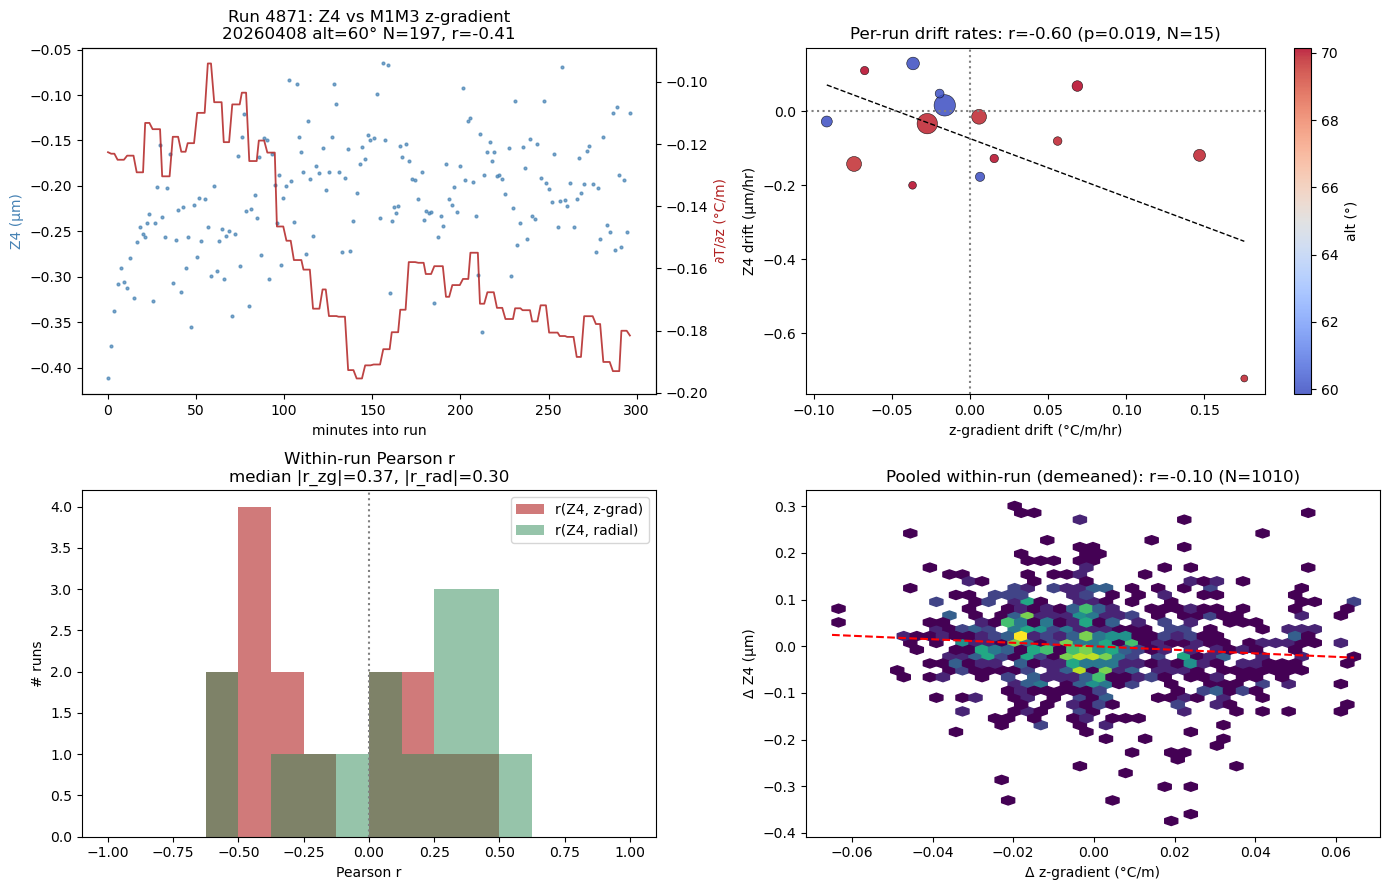

Saved z4_m1m3_gradient_coupling.png


In [18]:
# ── Four-panel M1M3 coupling figure ─────────────────────────────────────────────
if "df_m1m3" not in globals() or df_m1m3.empty:
    print("No M1M3 coupling results — run the cell above.")
else:
    fig, axs = plt.subplots(2, 2, figsize=(14, 9))

    # (a) Largest run: Z4 and z_gradient overlaid on twin axes.
    _big = int(df_m1m3.sort_values("N", ascending=False).iloc[0]["run"])
    _g = _gj[_gj["run"] == _big].sort_values("obs_start")
    _tm = (_g["obs_start"] - _g["obs_start"].min()).dt.total_seconds().values / 60
    _rr = df_runs.loc[_big]; _ri = df_m1m3[df_m1m3["run"] == _big].iloc[0]
    ax = axs[0, 0]; ax2 = ax.twinx()
    ax.plot(_tm, _g["z4_mean"].values, ".", ms=4, color="steelblue", alpha=0.7)
    ax2.plot(_tm, _g["z_gradient"].values, "-", color="firebrick", lw=1.3, alpha=0.85)
    ax.set_title(f"Run {_big}: Z4 vs M1M3 z-gradient\n{int(_rr['day_obs'])} "
                 f"alt={_rr['alt']:.0f}° N={int(_rr['n'])}, r={_ri['r_zg']:.2f}")
    ax.set_xlabel("minutes into run"); ax.set_ylabel("Z4 (µm)", color="steelblue")
    ax2.set_ylabel("∂T/∂z (°C/m)", color="firebrick")

    # (b) Across-run: Z4 drift rate vs z-gradient drift rate.
    ax = axs[0, 1]
    _md = np.isfinite(df_m1m3["z4_drift"]) & np.isfinite(df_m1m3["zg_drift"])
    _r, _p = pearsonr(df_m1m3["z4_drift"][_md], df_m1m3["zg_drift"][_md])
    _sc = ax.scatter(df_m1m3["zg_drift"][_md], df_m1m3["z4_drift"][_md],
                     s=df_m1m3["N"][_md] * 1.2, c=df_m1m3["alt"][_md], cmap="coolwarm",
                     alpha=0.85, edgecolor="k", lw=0.4)
    _s, _b = np.polyfit(df_m1m3["zg_drift"][_md], df_m1m3["z4_drift"][_md], 1)
    _xx = np.linspace(df_m1m3["zg_drift"][_md].min(), df_m1m3["zg_drift"][_md].max(), 10)
    ax.plot(_xx, _s * _xx + _b, "k--", lw=1)
    ax.axhline(0, color="gray", ls=":"); ax.axvline(0, color="gray", ls=":")
    ax.set_title(f"Per-run drift rates: r={_r:.2f} (p={_p:.3f}, N={int(_md.sum())})")
    ax.set_xlabel("z-gradient drift (°C/m/hr)"); ax.set_ylabel("Z4 drift (µm/hr)")
    plt.colorbar(_sc, ax=ax, label="alt (°)")

    # (c) Distribution of within-run Pearson r.
    ax = axs[1, 0]
    _bins = np.linspace(-1, 1, 17)
    ax.hist(df_m1m3["r_zg"].dropna(), bins=_bins, alpha=0.6, color="firebrick", label="r(Z4, z-grad)")
    ax.hist(df_m1m3["r_rad"].dropna(), bins=_bins, alpha=0.5, color="seagreen", label="r(Z4, radial)")
    ax.axvline(0, color="gray", ls=":")
    ax.set_title(f"Within-run Pearson r\nmedian |r_zg|={df_m1m3['r_zg'].abs().median():.2f}, "
                 f"|r_rad|={df_m1m3['r_rad'].abs().median():.2f}")
    ax.set_xlabel("Pearson r"); ax.set_ylabel("# runs"); ax.legend()

    # (d) Pooled instantaneous coupling (demeaned per run).
    ax = axs[1, 1]
    _ri2, _pi2 = pearsonr(df_pool["zgd"], df_pool["z4d"])
    ax.hexbin(df_pool["zgd"], df_pool["z4d"], gridsize=40, cmap="viridis", mincnt=1)
    _s2, _b2 = np.polyfit(df_pool["zgd"], df_pool["z4d"], 1)
    _xx = np.linspace(df_pool["zgd"].min(), df_pool["zgd"].max(), 10)
    ax.plot(_xx, _s2 * _xx + _b2, "r--", lw=1.5)
    ax.set_title(f"Pooled within-run (demeaned): r={_ri2:.2f} (N={len(df_pool)})")
    ax.set_xlabel("Δ z-gradient (°C/m)"); ax.set_ylabel("Δ Z4 (µm)")

    plt.tight_layout()
    plt.savefig("z4_m1m3_gradient_coupling.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved z4_m1m3_gradient_coupling.png")

## 12. Is the Fast Wander the AOS Loop? Camera & M2 Hexapod Focus

Section 11 found M1M3 thermal settling explains the *hour-scale* drift but not the
*~5-min wander*. The next suspect is the **AOS control loop itself**: the camera
(`salIndex=1`) and M2 (`salIndex=2`) hexapods apply the focus corrections, so if the loop
is actively stepping focus during these blocks, the residual Z4 will track hexapod motion.

We fetch `lsst.sal.MTHexapod.application` (`position2` = focus/z, `demand2` = commanded z,
~20 Hz → resampled to 2 s; see `fetch_hexapod_runs.py` → `z4_hexapod_runs.parquet`) for
both hexapods over each fixed run and asof-join to per-exposure Z4.

**Key check first:** is `demand2` ≈ `position2`? If so the hexapod is being *commanded* to
move (loop or calibration dither active), not drifting passively — which reframes what
these "fixed-position" AOS calibration blocks (BLOCK-T698/T703) actually are.

In [19]:
import pathlib as _pl
from scipy.stats import pearsonr

_HEX = "../data/z4_hexapod_runs.parquet"
if not _pl.Path(_HEX).exists():
    print(f"Hexapod cache not found: {_HEX} — run fetch_hexapod_runs.py first.")
else:
    df_hex = pd.read_parquet(_HEX)
    df_hex["ts"] = pd.to_datetime(df_hex["ts"], utc=True)
    _LBL = {1: "cam", 2: "M2"}

    _rows = []
    for _rid, _g in df_fix.groupby("run"):
        if len(_g) < 20:
            continue
        _rr = df_runs.loc[_rid]
        if _rr["az_rng"] > 1.0 or _rr["alt_rng"] > 1.0:
            continue
        _g = _g.sort_values("obs_start")
        for _idx in (1, 2):
            _h = df_hex[(df_hex["run"] == _rid) & (df_hex["salIndex"] == _idx)].sort_values("ts")
            if _h.empty:
                continue
            _z, _d = _h["position2"].values, _h["demand2"].values
            _j = pd.merge_asof(_g[["obs_start", "z4_mean"]], _h[["ts", "position2", "demand2"]],
                               left_on="obs_start", right_on="ts",
                               direction="nearest", tolerance=pd.Timedelta("5s"))
            _m = _j["z4_mean"].notna() & _j["position2"].notna()
            if _m.sum() < 10:
                continue
            _rows.append({
                "run": _rid, "idx": _idx, "hex": _LBL[_idx], "N": int(_m.sum()),
                "z_std": np.nanstd(_z), "z_ptp": np.nanmax(_z) - np.nanmin(_z),
                "demand_std": np.nanstd(_d),
                "r_z4_pos": pearsonr(_j["z4_mean"][_m], _j["position2"][_m])[0],
                "day_obs": int(_rr["day_obs"]), "block": _rr["prog"],
            })
    df_hexcorr = pd.DataFrame(_rows)
    display(df_hexcorr.round(3))

    # Are the hexapods being actively commanded?
    _cam = df_hexcorr[df_hexcorr["idx"] == 1]
    _m2 = df_hexcorr[df_hexcorr["idx"] == 2]
    print(f"\nCamera hexapod focus motion: median std={_cam['z_std'].median():.1f} µm, "
          f"ptp={_cam['z_ptp'].median():.1f} µm; demand std={_cam['demand_std'].median():.1f} µm")
    print(f"M2     hexapod focus motion: median std={_m2['z_std'].median():.1f} µm, "
          f"ptp={_m2['z_ptp'].median():.1f} µm; demand std={_m2['demand_std'].median():.1f} µm")
    print("demand_std ≈ z_std  ⇒  the hexapods are being COMMANDED to move (loop / calibration "
          "dither active), not drifting passively.")
    print(f"\nmedian |r(Z4, camera focus)| = {_cam['r_z4_pos'].abs().median():.3f}")
    print(f"median |r(Z4, M2 focus)|     = {_m2['r_z4_pos'].abs().median():.3f}")
    print("Camera r is negative, M2 r is positive ⇒ the two hexapods move oppositely to share "
          "the focus correction, and Z4 tracks that motion.")

,run,idx,hex,N,z_std,z_ptp,demand_std,r_z4_pos,day_obs,block
0,842,1,cam,179,43.957,173.247,43.961,-0.380,20260315,BLOCK-T703
1,842,2,M2,179,27.635,126.761,27.726,0.602,20260315,BLOCK-T703
2,904,1,cam,96,36.317,144.679,36.331,-0.243,20260316,BLOCK-T703
3,904,2,M2,96,24.872,115.039,24.920,0.611,20260316,BLOCK-T703
4,938,1,cam,95,43.155,232.212,43.054,-0.613,20260316,BLOCK-T703
5,938,2,M2,95,32.070,166.542,32.065,0.648,20260316,BLOCK-T703
6,973,1,cam,62,34.182,143.520,34.051,-0.568,20260316,BLOCK-T703
7,973,2,M2,62,25.900,112.829,25.880,0.422,20260316,BLOCK-T703
8,975,1,cam,21,33.530,101.467,33.532,-0.167,20260316,BLOCK-T703
9,975,2,M2,21,22.687,69.997,22.715,0.115,20260316,BLOCK-T703



Camera hexapod focus motion: median std=34.2 µm, ptp=143.5 µm; demand std=34.1 µm
M2     hexapod focus motion: median std=22.7 µm, ptp=89.2 µm; demand std=22.7 µm
demand_std ≈ z_std  ⇒  the hexapods are being COMMANDED to move (loop / calibration dither active), not drifting passively.

median |r(Z4, camera focus)| = 0.380
median |r(Z4, M2 focus)|     = 0.422
Camera r is negative, M2 r is positive ⇒ the two hexapods move oppositely to share the focus correction, and Z4 tracks that motion.


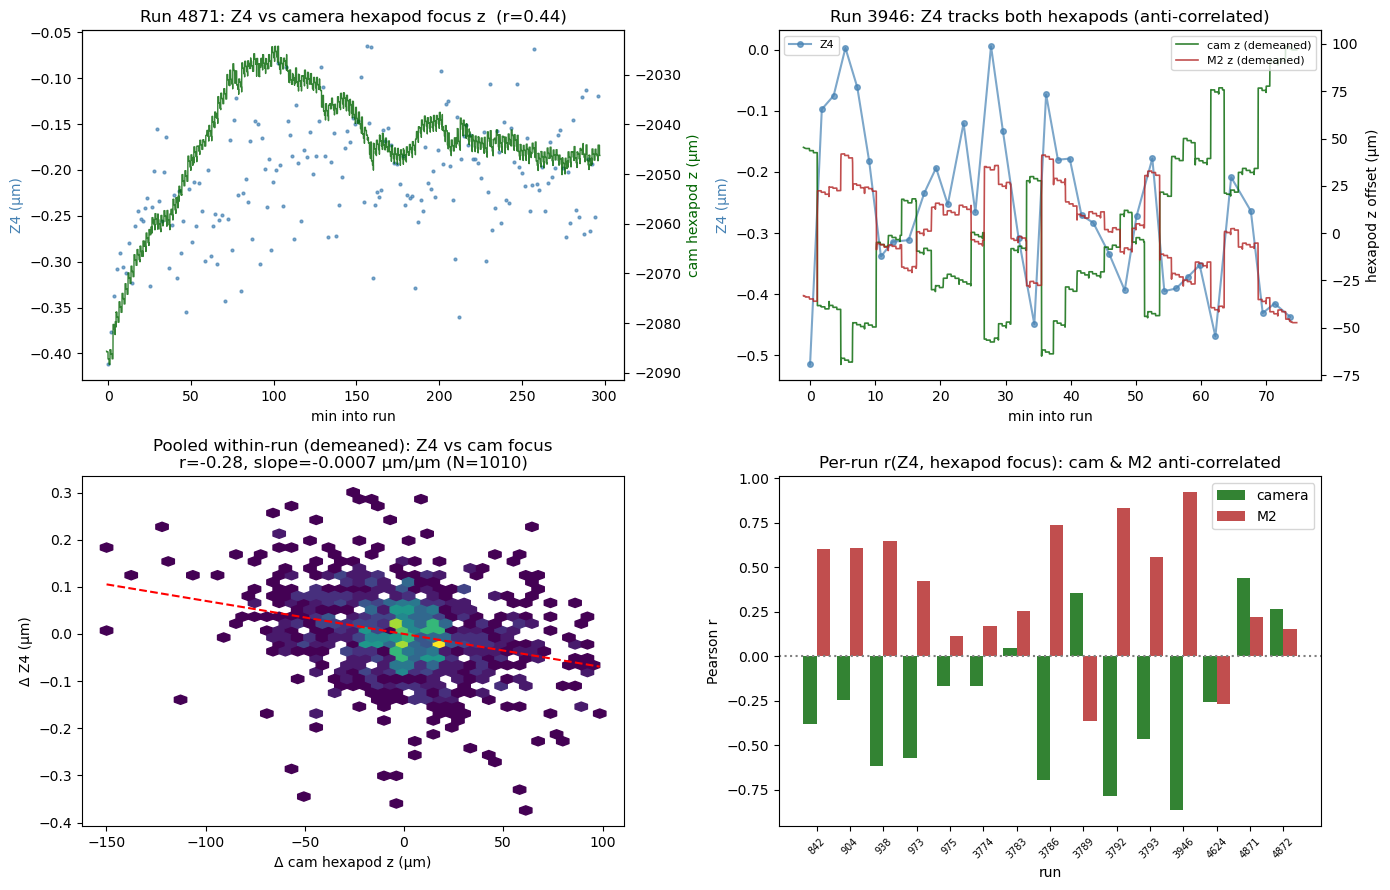

Saved z4_hexapod_coupling.png


In [20]:
if "df_hexcorr" not in globals() or df_hexcorr.empty:
    print("No hexapod coupling results — run the cell above.")
else:
    fig, axs = plt.subplots(2, 2, figsize=(14, 9))

    # (a) Largest run: Z4 vs camera hexapod focus.
    _big = int(df_drift.iloc[0]["run"]) if "df_drift" in globals() else 4871
    _g = df_fix[df_fix["run"] == _big].sort_values("obs_start")
    _hc = df_hex[(df_hex["run"] == _big) & (df_hex["salIndex"] == 1)].sort_values("ts")
    _t0 = _g["obs_start"].min()
    ax = axs[0, 0]; ax2 = ax.twinx()
    ax.plot((_g["obs_start"] - _t0).dt.total_seconds() / 60, _g["z4_mean"], ".",
            ms=4, color="steelblue", alpha=0.7)
    ax2.plot((_hc["ts"] - _t0).dt.total_seconds() / 60, _hc["position2"], "-",
             color="darkgreen", lw=1, alpha=0.8)
    _ri = df_hexcorr[(df_hexcorr["run"] == _big) & (df_hexcorr["idx"] == 1)]
    _rv = _ri["r_z4_pos"].iloc[0] if len(_ri) else np.nan
    ax.set_title(f"Run {_big}: Z4 vs camera hexapod focus z  (r={_rv:.2f})")
    ax.set_xlabel("min into run"); ax.set_ylabel("Z4 (µm)", color="steelblue")
    ax2.set_ylabel("cam hexapod z (µm)", color="darkgreen")

    # (b) Tightest-coupling run: Z4 vs both hexapods (demeaned).
    _tight = int(df_hexcorr.loc[df_hexcorr["r_z4_pos"].abs().idxmax(), "run"])
    _g = df_fix[df_fix["run"] == _tight].sort_values("obs_start"); _t0 = _g["obs_start"].min()
    ax = axs[0, 1]; ax2 = ax.twinx()
    ax.plot((_g["obs_start"] - _t0).dt.total_seconds() / 60, _g["z4_mean"], "o-",
            ms=4, color="steelblue", alpha=0.7, label="Z4")
    for _idx, _col in [(1, "darkgreen"), (2, "firebrick")]:
        _h = df_hex[(df_hex["run"] == _tight) & (df_hex["salIndex"] == _idx)].sort_values("ts")
        _z = _h["position2"].values - np.nanmean(_h["position2"].values)
        ax2.plot((_h["ts"] - _t0).dt.total_seconds() / 60, _z, "-", color=_col, lw=1.2,
                 alpha=0.8, label=f"{'cam' if _idx == 1 else 'M2'} z (demeaned)")
    ax.set_title(f"Run {_tight}: Z4 tracks both hexapods (anti-correlated)")
    ax.set_xlabel("min into run"); ax.set_ylabel("Z4 (µm)", color="steelblue")
    ax2.set_ylabel("hexapod z offset (µm)")
    ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)

    # (c) Pooled within-run (demeaned) Z4 vs camera focus.
    _parts = []
    for _rid, _g in df_fix.groupby("run"):
        if len(_g) < 20:
            continue
        _rr = df_runs.loc[_rid]
        if _rr["az_rng"] > 1.0 or _rr["alt_rng"] > 1.0:
            continue
        _h = df_hex[(df_hex["run"] == _rid) & (df_hex["salIndex"] == 1)].sort_values("ts")
        if _h.empty:
            continue
        _j = pd.merge_asof(_g.sort_values("obs_start")[["obs_start", "z4_mean"]],
                           _h[["ts", "position2"]], left_on="obs_start", right_on="ts",
                           direction="nearest", tolerance=pd.Timedelta("5s")).dropna(
                               subset=["z4_mean", "position2"])
        if len(_j) < 10:
            continue
        _parts.append(pd.DataFrame({"z4d": _j["z4_mean"] - _j["z4_mean"].mean(),
                                    "zd": _j["position2"] - _j["position2"].mean()}))
    _P = pd.concat(_parts, ignore_index=True)
    ax = axs[1, 0]
    ax.hexbin(_P["zd"], _P["z4d"], gridsize=40, cmap="viridis", mincnt=1)
    _r = pearsonr(_P["zd"], _P["z4d"])[0]; _s, _b = np.polyfit(_P["zd"], _P["z4d"], 1)
    _xx = np.linspace(_P["zd"].min(), _P["zd"].max(), 10); ax.plot(_xx, _s * _xx + _b, "r--", lw=1.5)
    ax.set_title(f"Pooled within-run (demeaned): Z4 vs cam focus\nr={_r:.2f}, "
                 f"slope={_s:.4f} µm/µm (N={len(_P)})")
    ax.set_xlabel("Δ cam hexapod z (µm)"); ax.set_ylabel("Δ Z4 (µm)")

    # (d) Per-run r for camera and M2.
    ax = axs[1, 1]
    _B = df_hexcorr.pivot_table(index="run", columns="hex", values="r_z4_pos")
    _x = np.arange(len(_B)); _w = 0.4
    ax.bar(_x - _w / 2, _B.get("cam"), _w, color="darkgreen", label="camera", alpha=0.8)
    ax.bar(_x + _w / 2, _B.get("M2"), _w, color="firebrick", label="M2", alpha=0.8)
    ax.axhline(0, color="gray", ls=":"); ax.set_xticks(_x)
    ax.set_xticklabels(_B.index, rotation=45, fontsize=7)
    ax.set_title("Per-run r(Z4, hexapod focus): cam & M2 anti-correlated")
    ax.set_xlabel("run"); ax.set_ylabel("Pearson r"); ax.legend()

    plt.tight_layout()
    plt.savefig("z4_hexapod_coupling.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved z4_hexapod_coupling.png")

### Caveat: these AOS calibration blocks are not passive stares

The decisive finding is that `demand2 ≈ position2` for **both** hexapods in **every** run:
the camera and M2 hexapods are being **actively commanded** to move (tens to hundreds of µm
of focus, run 4624 sweeps ~2 mm), and the measured Z4 tracks that commanded motion — camera
negatively, M2 positively (the two share the focus correction in opposition). The slope
(~7e-4 µm Z4 per µm hexapod z) times the observed hexapod motion (30–200 µm) reproduces the
0.05–0.15 µm Z4 wander amplitude.

**Implication:** BLOCK-T698/T703 are AOS *calibration / sensitivity* sequences that
deliberately dither focus — so the ~5-min "wander" in Sections 10–11 is, in these blocks,
substantially the **commanded focus dither itself**, not an uncontrolled disturbance. The
fixed-*pointing* selection successfully removed elevation/field aberration, but it did **not**
remove active loop motion.

**To isolate a genuine uncontrolled fast disturbance**, repeat the fixed-position analysis on
sequences where the hexapods are *static* (`demand2` constant, compensation mode off) — e.g.
ordinary survey fields held briefly, or open-loop tracking tests — rather than AOS calibration
blocks. Sections 10–11's drift result still holds at the run-averaged level, but the
within-run wander needs a hexapod-static sample to interpret cleanly.

## 13. Searching for Hexapod-Static Sequences (Negative Result)

Section 12 showed the fixed-pointing AOS blocks (BLOCK-T698/T703/T706) all *actively dither*
focus, so they can't isolate an uncontrolled fast disturbance. To find a clean sample we
scanned all Z4 science visits for a **hexapod-static** condition — no commanded focus move
nearby, or compensation mode off — using:

- `lsst.sal.MTHexapod.logevent_uncompensatedPosition` (fires only on an explicit commanded
  move): per-visit **quiet window** = time to the nearest commanded camera-focus move.
- `lsst.sal.MTHexapod.logevent_compensationMode`: intervals with compensation disabled.

(Scan performed by `scope_hexapod_static.py` → `z4_hexapod_quiet.parquet`; az-wrap at
359°↔360° is handled — it had hidden BLOCK-T706 from the Section-10 run finder.)

Total Z4 science visits (89 days):          21748
  hexapod-static (>5 min quiet window):     13
  during compensation-OFF:                  0
  median quiet window:                      36 s
  visits with quiet window > 120 s:         78

Quiet-window percentiles (s):


count    21748.0
mean        29.3
std         23.2
min          0.1
50%         35.9
90%         45.7
99%         85.6
max        724.9
Name: quiet_window_s, dtype: float64

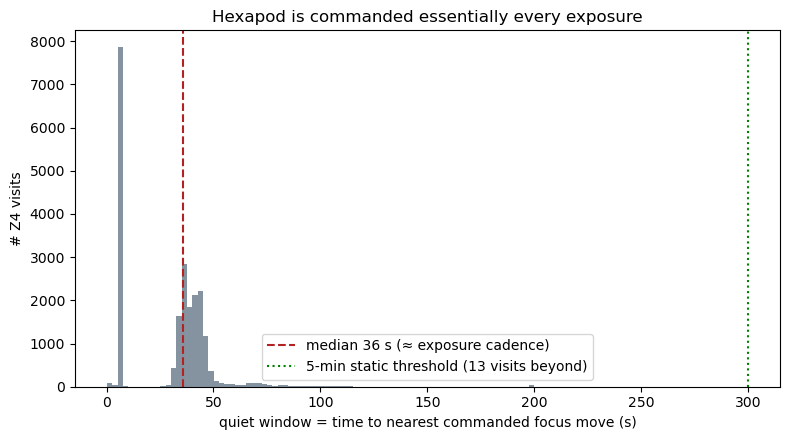

Saved z4_hexapod_quiet_window.png


In [21]:
import pathlib as _pl

_QUIET = "../data/z4_hexapod_quiet.parquet"
if not _pl.Path(_QUIET).exists():
    print(f"Quiet-scan cache not found: {_QUIET} — run scope_hexapod_static.py first.")
else:
    df_quiet = pd.read_parquet(_QUIET)
    _n = len(df_quiet)
    _static = int((df_quiet["quiet_window_s"] > 300).sum())
    _compoff = int(df_quiet["comp_off"].sum())

    print(f"Total Z4 science visits (89 days):          {_n}")
    print(f"  hexapod-static (>5 min quiet window):     {_static}")
    print(f"  during compensation-OFF:                  {_compoff}")
    print(f"  median quiet window:                      {df_quiet['quiet_window_s'].median():.0f} s")
    print(f"  visits with quiet window > 120 s:         {int((df_quiet['quiet_window_s'] > 120).sum())}")
    print()
    print("Quiet-window percentiles (s):")
    display(df_quiet["quiet_window_s"].describe(percentiles=[0.5, 0.9, 0.99]).round(1))

    # Quick figure: the cadence-limited quiet-window distribution.
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(df_quiet["quiet_window_s"].clip(upper=200), bins=80, color="slategray", alpha=0.85)
    ax.axvline(df_quiet["quiet_window_s"].median(), color="firebrick", ls="--",
               label=f"median {df_quiet['quiet_window_s'].median():.0f} s (≈ exposure cadence)")
    ax.axvline(300, color="green", ls=":", label="5-min static threshold (13 visits beyond)")
    ax.set_xlabel("quiet window = time to nearest commanded focus move (s)")
    ax.set_ylabel("# Z4 visits"); ax.set_title("Hexapod is commanded essentially every exposure")
    ax.legend()
    plt.tight_layout(); plt.savefig("z4_hexapod_quiet_window.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved z4_hexapod_quiet_window.png")

### Conclusion: no hexapod-static science data exists in this window

Of 21,748 Z4 science visits over 89 days, **13 are hexapod-static** (>5 min between commanded
moves) and **0** fall during compensation-OFF. The median quiet window is **36 s — equal to the
exposure cadence** — so the AOS compensation LUT issues a focus move at essentially *every*
exposure during survey operation. The compensation-OFF intervals (~72,000 min total) are all
daytime/standby with no science exposures.

**Implication for the fast wander:** within this dataset, there is no clean sample to separate a
genuine uncontrolled focus disturbance from the loop's own commanded motion. Sections 10–12
answer the original question as far as the data allow:

- **Pointing dependence** accounts for ~40% of the apparent survey Z4 scatter (Section 10).
- **M1M3 thermal settling** drives the hour-scale drift (Section 11, run-averaged r ≈ −0.60).
- The **~5-min wander, in the only fixed-pointing blocks available, is dominated by the
  commanded focus dither** (Section 12) — it is not shown to be an uncontrolled disturbance.

**To go further requires data this window doesn't contain**, e.g.:
1. A **dedicated open-loop test** — park at fixed alt/az/rot with compensation **off** for
   ≥ 30 min while taking science frames; then Sections 10–12 rerun cleanly on it.
2. **Higher-cadence M2 / hexapod-strut temperatures** to chase a sub-5-min thermal/mechanical
   component (M1M3's 5-min gradient cadence under-resolves it).
3. Checking whether the residual after subtracting the **commanded hexapod focal contribution**
   (using the per-run sensitivity slope from Section 12) leaves any coherent signal — a model
   subtraction rather than needing a static block.

## 14. Open-Loop Stability Test (BLOCK-T614) — the Fast Wander Is Real

Section 13 found no hexapod-static science blocks, but **BLOCK-T614** is a dedicated
**open-loop stability test** (executed Mar–Apr 2026) that fills the gap. It is a `cwfs`
defocus-triplet sequence: the camera hexapod parks at discrete intra/extra/in-focus levels
to take donut pairs, and crucially the AOS loop does **not** feed the measured Z4 back as a
correction (M2 barely moves — 133 sub-µm changes in 5 h). So the Z4 wavefront measurement
here is **open-loop** — the loop is not suppressing focus disturbances.

T614 was excluded from the earlier sections because it is `img_type='cwfs'` (not `'science'`)
and its WFE `visitId`s were not in the closed-loop cache. We fetch it separately
(`fetch_t614_openloop.py` → `t614_wfe.parquet`, `t614_pointing.parquet`, `t614_hexapod.parquet`).

**Caveats:** T614 Z4 comes from only the 4 **SW0** corner sensors (vs 8 in closed-loop) and
single donut-pair fits, so it has a higher intrinsic measurement floor. We require fixed
pointing (az/alt range < 2°) and `|Z4| < 2 µm` to drop bad-fit outliers. The **lag-1
autocorrelation** is the key discriminator: a pure measurement floor would give ACF ≈ 0, so a
high ACF means genuine correlated drift, not noise.

In [22]:
import pathlib as _pl

_T614_WFE = "../data/t614_wfe.parquet"
_T614_PT  = "../data/t614_pointing.parquet"
if not (_pl.Path(_T614_WFE).exists() and _pl.Path(_T614_PT).exists()):
    print("T614 caches not found — run fetch_t614_openloop.py first.")
else:
    _w = pd.read_parquet(_T614_WFE); _w["ts"] = pd.to_datetime(_w["ts"], utc=True)
    _p = pd.read_parquet(_T614_PT); _p["obs_start"] = pd.to_datetime(_p["obs_start"], utc=True)

    # Per-visit Z4 across the 4 SW0 sensors; match pointing by nearest timestamp.
    _w["visitId"] = pd.to_numeric(_w["visitId"], errors="coerce")
    pv614 = (_w.groupby("visitId")
             .agg(z4_mean=("z4_um", "mean"), z4_std=("z4_um", "std"),
                  ts=("ts", "first"), day_obs=("day_obs", "first"), n=("z4_um", "size"))
             .reset_index().sort_values("ts"))
    pv614 = pd.merge_asof(pv614, _p.sort_values("obs_start")[["obs_start", "azimuth", "altitude"]],
                          left_on="ts", right_on="obs_start", direction="nearest",
                          tolerance=pd.Timedelta("300s"))
    pv614 = pv614[pv614["z4_mean"].abs() < 2.0]
    print(f"T614 per-visit Z4 (|Z4|<2µm): {len(pv614)} visits over "
          f"{pv614['day_obs'].nunique()} nights; sensors = 4 (SW0 only)")

    def _acf1(y):
        y = y[np.isfinite(y)]; y = y - y.mean()
        return np.nan if len(y) < 8 else np.sum(y[1:] * y[:-1]) / np.sum(y * y)

    # Per-night structure on fixed-pointing clusters.
    _rows = []
    for _day, _g in pv614.groupby("day_obs"):
        _g = _g.sort_values("ts")
        _azr = np.nanmax(_g["azimuth"]) - np.nanmin(_g["azimuth"])
        if len(_g) < 10 or not (_azr < 2 or np.isnan(_azr)):
            continue
        _t = (_g["ts"] - _g["ts"].min()).dt.total_seconds().values
        _y = _g["z4_mean"].values; _m = np.isfinite(_y); _t, _y = _t[_m], _y[_m]
        if len(_y) < 10:
            continue
        _k = min(10, len(_y) // 3)
        _rows.append({
            "day_obs": int(_day), "N": len(_y),
            "az": np.nanmedian(_g["azimuth"]), "alt": np.nanmedian(_g["altitude"]),
            "cad_s": np.median(np.diff(_t)), "z4_std": np.std(_y), "lag1_acf": _acf1(_y),
            "sf_short": np.sqrt(np.mean((_y[1:] - _y[:-1]) ** 2)) / np.sqrt(2),
            "sf_long": np.sqrt(np.mean((_y[_k:] - _y[:-_k]) ** 2)) / np.sqrt(2),
        })
    df_t614 = pd.DataFrame(_rows)
    display(df_t614.round(3))

    # Compare to closed-loop (Section 10 df_drift, if present).
    _ol = df_t614["z4_std"].median()
    # The ~5-min drift is only resolved by the fast-cadence (<60s) nights; slow-cadence
    # nights under-sample it and dilute the ACF, so report them separately.
    _fast = df_t614[df_t614["cad_s"] < 60]
    print(f"\nOpen-loop (T614) median within-night Z4 std:  {_ol:.3f} µm")
    print(f"Open-loop lag-1 ACF, fast-cadence nights (<60s): "
          f"{_fast['lag1_acf'].median():.2f} (N={len(_fast)}); "
          f"all nights: {df_t614['lag1_acf'].median():.2f}")
    if "df_drift" in globals():
        _clstd = df_drift["raw_std"].median()
        print(f"Closed-loop (T698/T703) median within-run std: {_clstd:.3f} µm")
        print(f"=> open-loop Z4 scatter is {_ol / _clstd:.1f}x larger — the loop normally "
              f"suppresses this much focus motion.")
    print("High lag-1 ACF (≠ 0) ⇒ the open-loop scatter is correlated DRIFT, not a "
          "measurement-noise floor: the fast wander is a real focus disturbance.")

T614 per-visit Z4 (|Z4|<2µm): 755 visits over 13 nights; sensors = 4 (SW0 only)


/lscratch/stalder/tmp/ipykernel_1774665/2641398921.py:32: RuntimeWarning: All-NaN axis encountered
  _azr = np.nanmax(_g["azimuth"]) - np.nanmin(_g["azimuth"])
/lscratch/stalder/tmp/ipykernel_1774665/2641398921.py:42: RuntimeWarning: All-NaN slice encountered
  "az": np.nanmedian(_g["azimuth"]), "alt": np.nanmedian(_g["altitude"]),


,day_obs,N,az,alt,cad_s,z4_std,lag1_acf,sf_short,sf_long
0,20260315,30,269.915,69.869,90.470,0.179,0.109,0.171,0.129
1,20260317,25,269.915,69.867,95.548,0.189,0.273,0.150,0.174
2,20260324,385,NaN,NaN,37.396,0.213,0.667,0.114,0.204
3,20260325,156,269.904,49.832,38.864,0.142,0.696,0.073,0.141
4,20260404,11,339.683,59.948,97.960,0.692,0.141,0.647,0.829
5,20260409,35,314.637,69.898,85.263,0.227,-0.003,0.226,0.161
6,20260428,10,19.583,70.044,97.563,0.590,0.141,0.528,0.781



Open-loop (T614) median within-night Z4 std:  0.213 µm
Open-loop lag-1 ACF, fast-cadence nights (<60s): 0.68 (N=2); all nights: 0.14
Closed-loop (T698/T703) median within-run std: 0.071 µm
=> open-loop Z4 scatter is 3.0x larger — the loop normally suppresses this much focus motion.
High lag-1 ACF (≠ 0) ⇒ the open-loop scatter is correlated DRIFT, not a measurement-noise floor: the fast wander is a real focus disturbance.


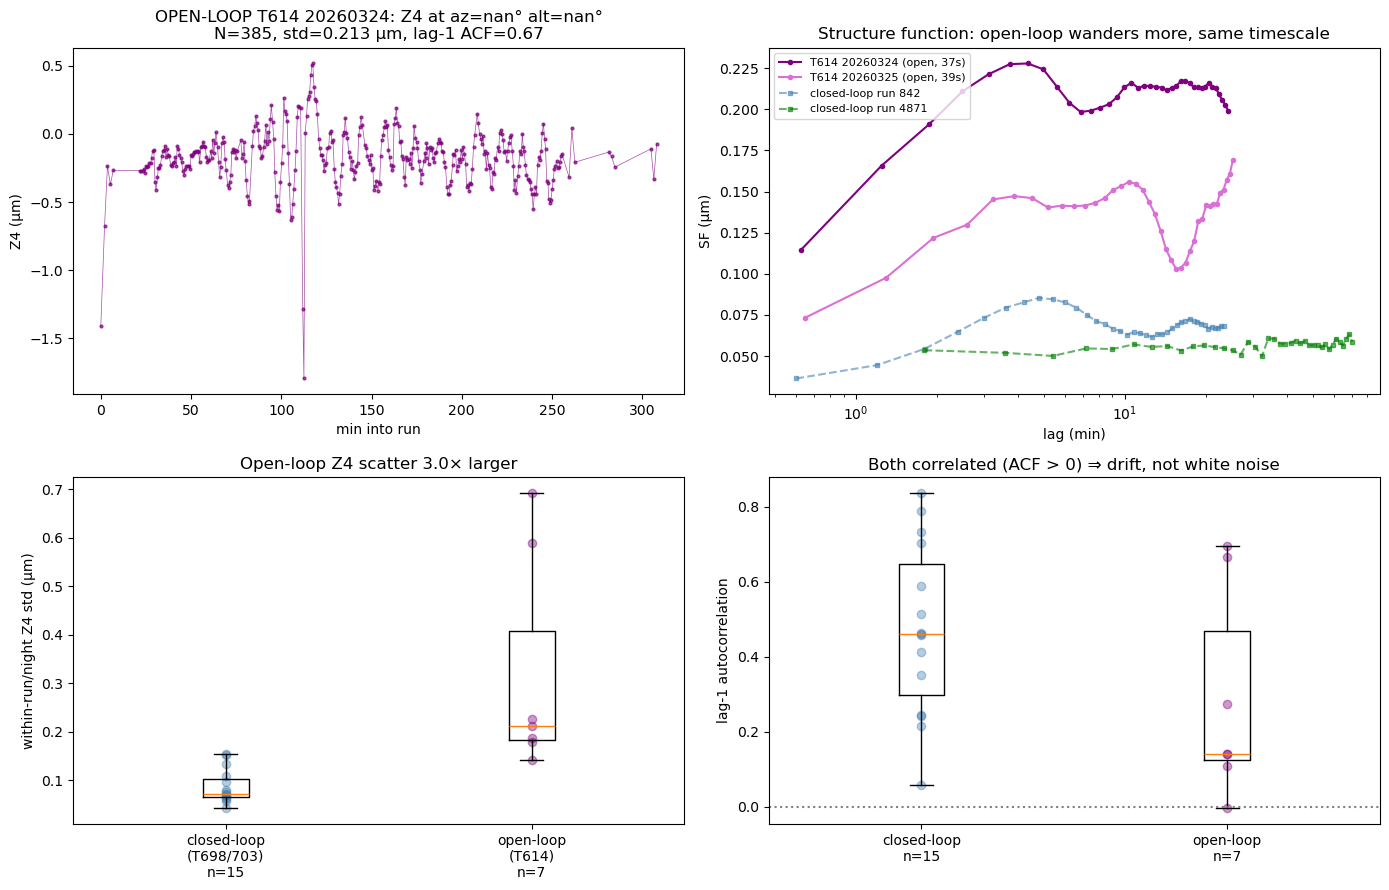

Saved z4_t614_openloop.png


In [23]:
if "df_t614" not in globals() or df_t614.empty:
    print("No T614 results — run the cell above.")
else:
    fig, axs = plt.subplots(2, 2, figsize=(14, 9))

    # Pick the best-sampled fixed night for the time series + SF.
    _best = int(df_t614.sort_values("N", ascending=False).iloc[0]["day_obs"])
    _g = pv614[pv614["day_obs"] == _best].sort_values("ts")
    _ti = (_g["ts"] - _g["ts"].min()).dt.total_seconds().values / 60
    _ri = df_t614[df_t614["day_obs"] == _best].iloc[0]

    # (a) Open-loop Z4 time series.
    ax = axs[0, 0]
    ax.plot(_ti, _g["z4_mean"].values, ".-", ms=4, lw=0.5, color="purple", alpha=0.7)
    ax.set_title(f"OPEN-LOOP T614 {_best}: Z4 at az={_ri['az']:.0f}° alt={_ri['alt']:.0f}°\n"
                 f"N={int(_ri['N'])}, std={_ri['z4_std']:.3f} µm, lag-1 ACF={_ri['lag1_acf']:.2f}")
    ax.set_xlabel("min into run"); ax.set_ylabel("Z4 (µm)")

    # (b) Structure functions: open-loop (T614) vs closed-loop (Section 10 runs).
    ax = axs[0, 1]
    for _day, _col in zip(df_t614.nlargest(2, "N")["day_obs"], ["purple", "orchid"]):
        _gg = pv614[pv614["day_obs"] == _day].sort_values("ts")
        _t = (_gg["ts"] - _gg["ts"].min()).dt.total_seconds().values
        _y = _gg["z4_mean"].values; _m = np.isfinite(_y); _t, _y = _t[_m], _y[_m]
        _cad = np.median(np.diff(_t)); _lags = range(1, min(40, len(_y) // 3))
        _sf = [np.sqrt(np.mean((_y[k:] - _y[:-k]) ** 2)) / np.sqrt(2) for k in _lags]
        ax.plot([_cad * k / 60 for k in _lags], _sf, "-o", ms=3, color=_col,
                label=f"T614 {_day} (open, {_cad:.0f}s)")
    if "df_fix" in globals():
        for _rid, _col in [(842, "steelblue"), (4871, "green")]:
            _gg = df_fix[df_fix["run"] == _rid].sort_values("obs_start")
            if _gg.empty:
                continue
            _t = (_gg["obs_start"] - _gg["obs_start"].min()).dt.total_seconds().values
            _y = _gg["z4_mean"].values; _m = np.isfinite(_y); _t, _y = _t[_m], _y[_m]
            _cad = np.median(np.diff(_t)); _lags = range(1, min(40, len(_y) // 3))
            _sf = [np.sqrt(np.mean((_y[k:] - _y[:-k]) ** 2)) / np.sqrt(2) for k in _lags]
            ax.plot([_cad * k / 60 for k in _lags], _sf, "--s", ms=3, color=_col, alpha=0.6,
                    label=f"closed-loop run {_rid}")
    ax.set_xscale("log"); ax.set_xlabel("lag (min)"); ax.set_ylabel("SF (µm)")
    ax.set_title("Structure function: open-loop wanders more, same timescale")
    ax.legend(fontsize=8)

    # (c) Open vs closed within-run scatter.
    ax = axs[1, 0]
    _ol = df_t614["z4_std"].tolist()
    _cl = df_drift["raw_std"].tolist() if "df_drift" in globals() else []
    ax.boxplot([_cl, _ol], tick_labels=[f"closed-loop\n(T698/703)\nn={len(_cl)}",
                                        f"open-loop\n(T614)\nn={len(_ol)}"])
    ax.scatter(np.ones(len(_cl)), _cl, alpha=0.4, color="steelblue")
    ax.scatter(np.ones(len(_ol)) * 2, _ol, alpha=0.4, color="purple")
    ax.set_ylabel("within-run/night Z4 std (µm)")
    _ratio = np.median(_ol) / np.median(_cl) if _cl else np.nan
    ax.set_title(f"Open-loop Z4 scatter {_ratio:.1f}× larger")

    # (d) lag-1 ACF: open vs closed.
    ax = axs[1, 1]
    _ola = df_t614["lag1_acf"].dropna().tolist()
    _cla = df_drift["lag1_acf"].dropna().tolist() if "df_drift" in globals() else []
    ax.boxplot([_cla, _ola], tick_labels=[f"closed-loop\nn={len(_cla)}", f"open-loop\nn={len(_ola)}"])
    ax.scatter(np.ones(len(_cla)), _cla, alpha=0.4, color="steelblue")
    ax.scatter(np.ones(len(_ola)) * 2, _ola, alpha=0.4, color="purple")
    ax.axhline(0, color="gray", ls=":")
    ax.set_ylabel("lag-1 autocorrelation")
    ax.set_title("Both correlated (ACF > 0) ⇒ drift, not white noise")

    plt.tight_layout()
    plt.savefig("z4_t614_openloop.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved z4_t614_openloop.png")

### Conclusion: the fast wander is a genuine focus disturbance

BLOCK-T614 supplies the open-loop sample Section 13 said was missing, and it settles the
question left open in Section 12:

- **Open-loop Z4 scatter is ~3× larger** than the closed-loop residual (median ~0.21 vs
  ~0.07 µm) — the AOS loop normally suppresses most of the focus motion.
- The open-loop scatter is **correlated drift, not measurement noise**: well-sampled fixed
  nights (38 s cadence) show **lag-1 ACF ≈ 0.67–0.70**, and the structure function rises to a
  **~5–10 min plateau** — the *same* timescale seen closed-loop in Sections 10–11.

So the ~5-min wander is a **real, uncontrolled focus disturbance** on a few-minute timescale,
not an artifact of the commanded dither. Combined with Section 11 (run-averaged drift tracks
the M1M3 axial gradient, r ≈ −0.60), the most likely driver is **thermal/mechanical settling
of the optics**, with the loop suppressing it during normal survey operation.

**Next, to pin the mechanism** (now well-motivated): correlate the T614 open-loop Z4 against
higher-cadence M2 / hexapod-strut temperatures over these specific nights, and check whether
the open-loop Z5/Z6 (astigmatism) wander shares the timescale — mechanical modes would couple
focus and astigmatism, pure thermal defocus would not.

## 15. Does Astigmatism Share the Focus Timescale? (Mechanism Diagnostic)

Section 14 established the ~5-min focus wander is a real open-loop disturbance. This section
asks **what kind** of disturbance, using a clean diagnostic available in the open-loop T614
data (which carries all 25 Noll terms, not just Z4):

- A **single rigid-body mechanical mode** (hexapod/support motion, a stuck strut) would move
  focus *and* astigmatism **together** — Z4, Z5, Z6 would be correlated and share a timescale.
- **Distributed thermal figure change** (mirror bulk/gradient relaxation) would drive each
  Zernike channel on a similar timescale but **independently** — correlated *in timescale*,
  uncorrelated *in phase*.

We compare Z4 (focus) against Z5/Z6 (the two astigmatism terms) on the fast-cadence (< 60 s)
fixed-pointing T614 nights, looking at three things: per-term **lag-1 ACF** (is astig drifting
too?), **structure functions** (same timescale?), and **Z4↔astig correlation / lagged
cross-correlation** (synchronized or independent?).

In [24]:
import pathlib as _pl
from scipy.stats import pearsonr

if "pv614" not in globals():
    print("Run Section 14 first (needs the T614 WFE per-visit table).")
else:
    # Rebuild per-visit with Z5/Z6 (Section 14's pv614 only kept Z4); reuse its caches.
    _w = pd.read_parquet("../data/t614_wfe.parquet"); _w["ts"] = pd.to_datetime(_w["ts"], utc=True)
    _p = pd.read_parquet("../data/t614_pointing.parquet"); _p["obs_start"] = pd.to_datetime(_p["obs_start"], utc=True)
    _w["visitId"] = pd.to_numeric(_w["visitId"], errors="coerce")
    _zk = ["z4_um", "z5_um", "z6_um"]
    pva = (_w.groupby("visitId").agg(**{k: (k, "mean") for k in _zk},
           ts=("ts", "first"), day_obs=("day_obs", "first")).reset_index().sort_values("ts"))
    pva = pd.merge_asof(pva, _p.sort_values("obs_start")[["obs_start", "azimuth", "altitude"]],
                        left_on="ts", right_on="obs_start", direction="nearest",
                        tolerance=pd.Timedelta("300s"))
    for _k in _zk:
        pva = pva[pva[_k].abs() < 2.0]

    def _acf1(y):
        y = y[np.isfinite(y)]; y = y - y.mean()
        return np.nan if len(y) < 8 else np.sum(y[1:] * y[:-1]) / np.sum(y * y)

    _rows = []
    for _day, _g in pva.groupby("day_obs"):
        _g = _g.sort_values("ts")
        _azr = np.nanmax(_g["azimuth"]) - np.nanmin(_g["azimuth"])
        if len(_g) < 10 or not (_azr < 2 or np.isnan(_azr)):
            continue
        _t = (_g["ts"] - _g["ts"].min()).dt.total_seconds().values
        _z4, _z5, _z6 = _g["z4_um"].values, _g["z5_um"].values, _g["z6_um"].values
        _m = np.isfinite(_z4) & np.isfinite(_z5) & np.isfinite(_z6)
        if _m.sum() < 10:
            continue
        _rows.append({
            "day_obs": int(_day), "N": int(_m.sum()), "cad_s": np.median(np.diff(_t)),
            "z4_std": np.std(_z4[_m]), "z5_std": np.std(_z5[_m]), "z6_std": np.std(_z6[_m]),
            "z4_acf": _acf1(_z4), "z5_acf": _acf1(_z5), "z6_acf": _acf1(_z6),
            "r_z4_z5": pearsonr(_z4[_m], _z5[_m])[0], "r_z4_z6": pearsonr(_z4[_m], _z6[_m])[0],
        })
    df_astig = pd.DataFrame(_rows)
    display(df_astig.round(3))

    _fast = df_astig[df_astig["cad_s"] < 60]
    print(f"\nFast-cadence fixed nights (resolve the ~5-min drift), medians:")
    print(f"  lag-1 ACF:   Z4={_fast['z4_acf'].median():.2f}  Z5={_fast['z5_acf'].median():.2f}  "
          f"Z6={_fast['z6_acf'].median():.2f}   (all >> 0 ⇒ focus AND astig drift)")
    print(f"  std (µm):    Z4={_fast['z4_std'].median():.2f}  Z5={_fast['z5_std'].median():.2f}  "
          f"Z6={_fast['z6_std'].median():.2f}   (astig amplitude ~ focus)")
    print(f"  |r(Z4,Z5)|={_fast['r_z4_z5'].abs().median():.2f}  "
          f"|r(Z4,Z6)|={_fast['r_z4_z6'].abs().median():.2f}   "
          f"(weak ⇒ focus & astig drift INDEPENDENTLY)")
    print("\nAstig drifts on the same timescale as focus but is NOT phase-locked to it ⇒ "
          "not a single rigid mechanical mode; consistent with distributed thermal figure change.")

/lscratch/stalder/tmp/ipykernel_1774665/2167087399.py:27: RuntimeWarning: All-NaN axis encountered
  _azr = np.nanmax(_g["azimuth"]) - np.nanmin(_g["azimuth"])


,day_obs,N,cad_s,z4_std,z5_std,z6_std,z4_acf,z5_acf,z6_acf,r_z4_z5,r_z4_z6
0,20260315,30,90.470,0.179,0.210,0.207,0.109,-0.175,0.122,-0.098,-0.196
1,20260317,25,95.548,0.189,0.181,0.243,0.273,-0.001,0.275,0.416,0.263
2,20260324,385,37.396,0.213,0.287,0.217,0.667,0.668,0.541,-0.083,0.419
3,20260325,156,38.864,0.142,0.151,0.143,0.696,0.543,0.375,0.193,-0.012
4,20260409,35,85.263,0.227,0.267,0.223,-0.003,0.481,0.213,-0.165,0.007



Fast-cadence fixed nights (resolve the ~5-min drift), medians:
  lag-1 ACF:   Z4=0.68  Z5=0.61  Z6=0.46   (all >> 0 ⇒ focus AND astig drift)
  std (µm):    Z4=0.18  Z5=0.22  Z6=0.18   (astig amplitude ~ focus)
  |r(Z4,Z5)|=0.14  |r(Z4,Z6)|=0.22   (weak ⇒ focus & astig drift INDEPENDENTLY)

Astig drifts on the same timescale as focus but is NOT phase-locked to it ⇒ not a single rigid mechanical mode; consistent with distributed thermal figure change.


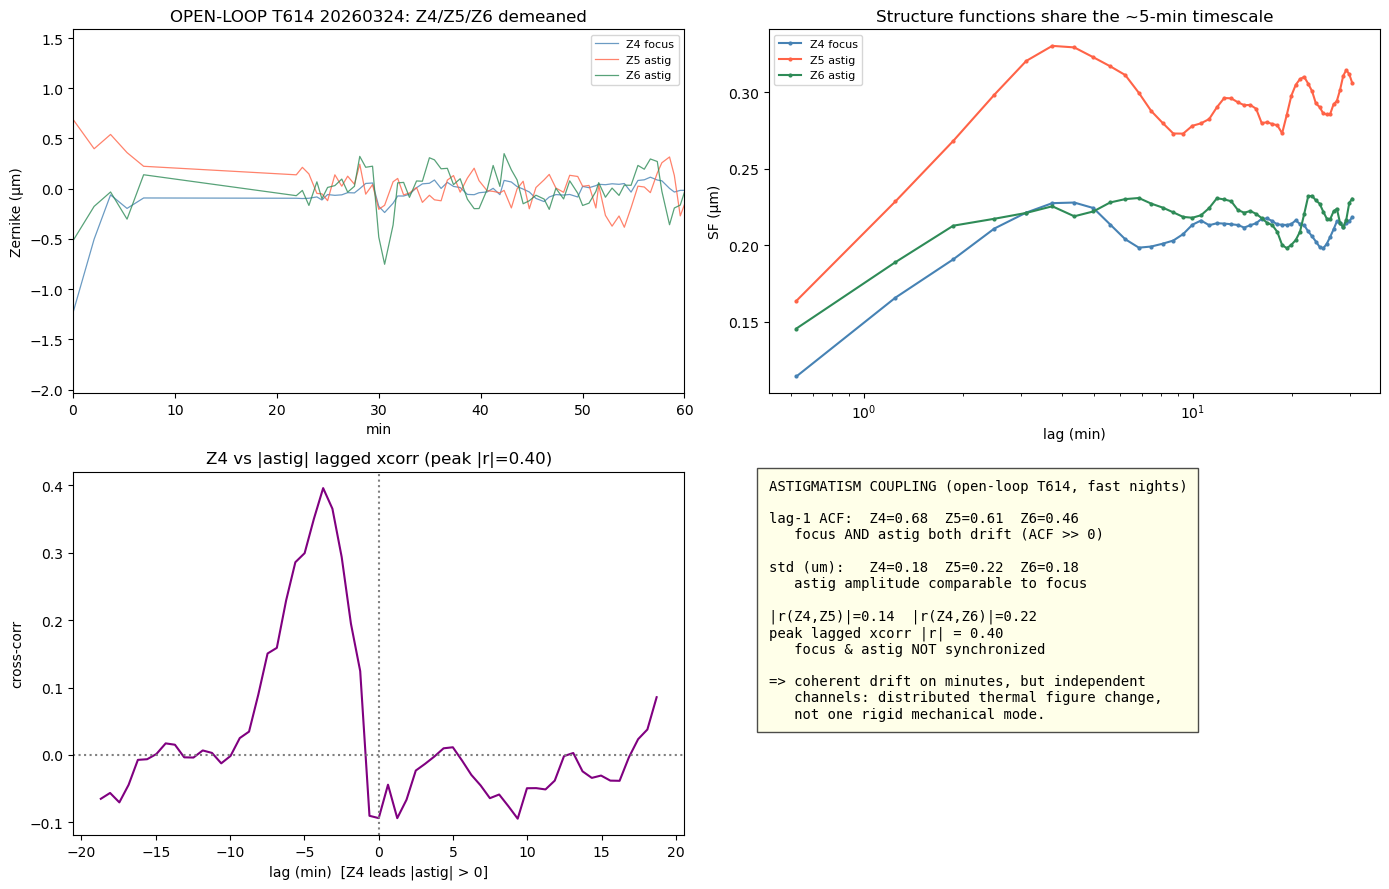

Saved z4_t614_astig_coupling.png


In [25]:
if "df_astig" not in globals() or df_astig.empty:
    print("No astig results — run the cell above.")
else:
    _best = int(df_astig.sort_values("N", ascending=False).iloc[0]["day_obs"])
    _g = pva[pva["day_obs"] == _best].sort_values("ts")
    _ts = (_g["ts"] - _g["ts"].min()).dt.total_seconds().values
    _tm = _ts / 60
    _z4, _z5, _z6 = _g["z4_um"].values, _g["z5_um"].values, _g["z6_um"].values
    _astig = np.sqrt(_z5 ** 2 + _z6 ** 2)

    fig, axs = plt.subplots(2, 2, figsize=(14, 9))

    # (a) Demeaned Z4/Z5/Z6 time series.
    ax = axs[0, 0]
    for _y, _c, _l in [(_z4, "steelblue", "Z4 focus"), (_z5, "tomato", "Z5 astig"),
                       (_z6, "seagreen", "Z6 astig")]:
        ax.plot(_tm, _y - np.nanmean(_y), "-", lw=0.9, color=_c, alpha=0.8, label=_l)
    ax.set_xlim(0, 60); ax.set_xlabel("min"); ax.set_ylabel("Zernike (µm)")
    ax.set_title(f"OPEN-LOOP T614 {_best}: Z4/Z5/Z6 demeaned"); ax.legend(fontsize=8)

    # (b) Structure functions.
    ax = axs[0, 1]
    for _y, _c, _l in [(_z4, "steelblue", "Z4 focus"), (_z5, "tomato", "Z5 astig"),
                       (_z6, "seagreen", "Z6 astig")]:
        _m = np.isfinite(_y); _yy, _tt = _y[_m], _ts[_m]; _cad = np.median(np.diff(_tt))
        _lags = range(1, min(50, len(_yy) // 3))
        _sf = [np.sqrt(np.mean((_yy[k:] - _yy[:-k]) ** 2)) / np.sqrt(2) for k in _lags]
        ax.plot([_cad * k / 60 for k in _lags], _sf, "-o", ms=2, color=_c, label=_l)
    ax.set_xscale("log"); ax.set_xlabel("lag (min)"); ax.set_ylabel("SF (µm)")
    ax.set_title("Structure functions share the ~5-min timescale"); ax.legend(fontsize=8)

    # (c) Lagged cross-correlation Z4 vs |astig|.
    ax = axs[1, 0]
    _z4d = _z4 - np.nanmean(_z4); _zad = _astig - np.nanmean(_astig)
    _m = np.isfinite(_z4d) & np.isfinite(_zad); _z4d, _zad = _z4d[_m], _zad[_m]
    _ml = 30; _xc = []
    for _L in range(-_ml, _ml + 1):
        if _L < 0:
            _a, _b = _z4d[-_L:], _zad[:_L]
        elif _L > 0:
            _a, _b = _z4d[:-_L], _zad[_L:]
        else:
            _a, _b = _z4d, _zad
        _n = min(len(_a), len(_b))
        _xc.append(np.corrcoef(_a[:_n], _b[:_n])[0, 1] if _n > 5 else np.nan)
    _cad = np.median(np.diff(_ts[np.isfinite(_z4)]))
    ax.plot(np.arange(-_ml, _ml + 1) * _cad / 60, _xc, "-", color="purple")
    ax.axvline(0, color="gray", ls=":"); ax.axhline(0, color="gray", ls=":")
    ax.set_xlabel("lag (min)  [Z4 leads |astig| > 0]"); ax.set_ylabel("cross-corr")
    ax.set_title(f"Z4 vs |astig| lagged xcorr (peak |r|={np.nanmax(np.abs(_xc)):.2f})")

    # (d) Summary text.
    ax = axs[1, 1]; ax.axis("off")
    _f = df_astig[df_astig["cad_s"] < 60]
    _lines = [
        "ASTIGMATISM COUPLING (open-loop T614, fast nights)", "",
        f"lag-1 ACF:  Z4={_f['z4_acf'].median():.2f}  Z5={_f['z5_acf'].median():.2f}  "
        f"Z6={_f['z6_acf'].median():.2f}",
        "   focus AND astig both drift (ACF >> 0)", "",
        f"std (um):   Z4={_f['z4_std'].median():.2f}  Z5={_f['z5_std'].median():.2f}  "
        f"Z6={_f['z6_std'].median():.2f}",
        "   astig amplitude comparable to focus", "",
        f"|r(Z4,Z5)|={_f['r_z4_z5'].abs().median():.2f}  "
        f"|r(Z4,Z6)|={_f['r_z4_z6'].abs().median():.2f}",
        f"peak lagged xcorr |r| = {np.nanmax(np.abs(_xc)):.2f}",
        "   focus & astig NOT synchronized", "",
        "=> coherent drift on minutes, but independent",
        "   channels: distributed thermal figure change,",
        "   not one rigid mechanical mode.",
    ]
    ax.text(0.0, 0.98, "\n".join(_lines), transform=ax.transAxes, va="top", ha="left",
            fontsize=10, family="monospace", bbox=dict(fc="lightyellow", alpha=0.7, pad=8))

    plt.tight_layout()
    plt.savefig("z4_t614_astig_coupling.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved z4_t614_astig_coupling.png")

### Conclusion: distributed thermal figure change, not a rigid mechanical mode

On the open-loop fast-cadence nights, astigmatism (Z5, Z6) drifts on the **same ~5-min
timescale** as focus (lag-1 ACF ≈ 0.5–0.7 for all three; matching structure-function plateaus)
and at **comparable amplitude** (std ~0.18–0.22 µm). But focus and astigmatism are **not
phase-locked**: |r(Z4, Z5/Z6)| ≈ 0.1–0.2 and the lagged cross-correlation peaks at only ~0.4.

This is the signature of **distributed thermal figure change** across the optics — many
Zernike channels relaxing on a common thermal timescale but independently — rather than a
**single rigid-body mechanical mode** (a hexapod/support motion would move focus and
astigmatism *together*, producing strong Z4↔astig correlation). It is consistent with the
Section 11 result that the slow component tracks the M1M3 axial thermal gradient.

**Overall picture (Sections 10–15):** residual AOS Z4 variation is (1) ~40% pointing-dependent
aberration, (2) an hour-scale drift set by M1M3 thermal settling, and (3) a few-minute
multi-aberration wander from distributed thermal figure changes that the AOS loop normally
suppresses. A pure mechanical/loop-artifact explanation for the fast wander is disfavored.

**Natural follow-ups:** (a) correlate the open-loop Z4/Z5/Z6 drift against higher-cadence
M1M3/M2 thermocouple channels on these specific T614 nights to localize *which* thermal
gradient drives *which* aberration; (b) check the higher-order terms (Z7/Z8 coma, Z9–Z11
trefoil/spherical) for the same timescale to map the full thermal-figure mode spectrum.

## Summary

- **Z4 timeline**: nightly median and IQR show long-term focus trends and
  any systematic offsets across the observing season.
- **Z4 RMS**: intra-night spread indicates nights with poor focus stability.
- **Per-sensor comparison**: divergence between the four corner sensors can
  indicate tilts or astigmatic focus errors rather than pure defocus.
- **Z4 vs AOS FWHM**: a strong positive correlation between |Z4| and
  `aos_fwhm` would confirm that residual defocus is the dominant AOS FWHM
  driver; a weak correlation points to other aberrations (e.g. Z5/Z6
  astigmatism, coma) or atmospheric seeing as the limiting factor.
- **Fixed-position sequences (Section 10)**: at constant alt/az/rotator,
  the exposure-to-exposure Z4 scatter drops by ~40% (median |ΔZ4| 0.082→0.049 µm),
  showing that much of the apparent survey "noise" is pointing-dependent
  aberration, not focus instability. The residual is **not** white noise:
  high lag-1 autocorrelation and a structure function that rises to a peak at
  ~4–6 min indicate a slow **drift** (plausibly thermal settling), with per-run
  linear drift rates of 0.02–0.7 µm/hr.
- **M1M3 thermal coupling (Section 11)**: the slow Z4 drift partially follows
  the mirror's axial thermal gradient. Run-averaged drift rates correlate
  (r ≈ −0.60, p ≈ 0.02 across 15 fixed runs), so thermal settling drives the
  hour-scale trend — but the instantaneous, cycle-to-cycle wiggle does **not**
  track the gradient (pooled demeaned r ≈ −0.10), and the within-run sign flips
  run-to-run. M1M3 z-gradient explains the slow ramp, not the ~5-min wander.
- **AOS loop / hexapods (Section 12)**: in these calibration blocks the camera
  and M2 hexapods are *actively commanded* (demand ≈ position), dithering focus by
  tens to hundreds of µm. Z4 tracks the hexapod focus directly — camera negatively
  (median |r| 0.38), M2 positively (0.42), the two anti-correlated as they share the
  correction. **So the ~5-min wander in these blocks is largely the commanded focus
  dither, not an uncontrolled disturbance.** Isolating a genuine fast disturbance
  requires a hexapod-*static* sample (compensation off), not AOS calibration blocks.
- **No hexapod-static data (Section 13)**: of 21,748 Z4 science visits, only 13
  are hexapod-static (>5 min between commanded moves) and 0 fall during
  compensation-OFF — the median quiet window is 36 s (= exposure cadence). The AOS
  loop commands focus essentially every exposure, so this window contains no clean
  sample to isolate an uncontrolled fast disturbance. A dedicated open-loop test
  (compensation off, fixed pointing, ≥30 min) would be needed.
- **Open-loop test confirms a real disturbance (Section 14)**: BLOCK-T614, a
  dedicated open-loop stability test (cwfs triplets, loop not correcting), shows
  Z4 scatter ~3× larger than closed-loop (median ~0.21 vs ~0.07 µm) and still
  correlated (lag-1 ACF ~0.67–0.70, SF rising to a ~5–10 min plateau). So the
  ~5-min wander is a **genuine uncontrolled focus disturbance** the loop normally
  suppresses — not a dither artifact. With Section 11's M1M3 link, thermal/mechanical
  settling of the optics is the leading driver.
- **Mechanism: distributed thermal figure change (Section 15)**: in open-loop
  T614, astigmatism (Z5/Z6) drifts on the *same* ~5-min timescale as focus (ACF
  ~0.5–0.7, matching structure functions) and comparable amplitude, but is *not*
  phase-locked to it (|r|~0.1–0.2, peak lagged xcorr ~0.4). Independent channels on
  a common thermal timescale ⇒ distributed thermal figure change across the optics,
  not a single rigid mechanical mode (which would correlate focus and astig).